In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# ALL COUNTRIES - STRICT AUDIT + COMPARISON BUNDLE
# One run -> one Excel workbook
# Uses the 4 country reporting bundles already created
# and pulls in sample/reference audit CSVs where available
# =========================================================

ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

BUNDLE_FILES = {
    "ES": ROOTS["ES"] / "ES_step1_final_reporting_bundle.xlsx",
    "BE": ROOTS["BE"] / "BE_step2_final_reporting_bundle.xlsx",
    "FI": ROOTS["FI"] / "FI_step3_final_reporting_bundle.xlsx",
    "RO": ROOTS["RO"] / "RO_step4_final_reporting_bundle.xlsx",
}

# Candidate audit/reference files
AUDIT_CANDIDATES = {
    "ES_common_cc": [
        ROOTS["ES"] / "ES_2007_2009_common_cc_summary.csv",
    ],
    "ES_reference": [
        ROOTS["ES"] / "ES_2007_2009_model_ready_reference_check.csv",
        ROOTS["ES"] / "ES_2007_2009_reference_summary.csv",
        ROOTS["ES"] / "ES_2007_2009_reference_summary_revised.csv",
    ],

    "BE_common_cc": [
        ROOTS["BE"] / "BE_2007_2009_common_cc_summary.csv",
    ],
    "BE_reference_summary": [
        ROOTS["BE"] / "BE_2007_2009_reference_summary_revised.csv",
        ROOTS["BE"] / "BE_2007_2009_reference_summary.csv",
    ],
    "BE_reference_check": [
        ROOTS["BE"] / "BE_2007_2009_model_ready_reference_check.csv",
        ROOTS["BE"] / "BE_2007_2009_model_ready_reference_order_check.csv",
    ],

    "FI_common_cc": [
        ROOTS["FI"] / "FI_2007_2009_common_cc_summary.csv",
    ],
    "FI_reference_summary": [
        ROOTS["FI"] / "FI_2007_2009_reference_summary_revised.csv",
        ROOTS["FI"] / "FI_2007_2009_reference_summary.csv",
    ],
    "FI_reference_check": [
        ROOTS["FI"] / "FI_2007_2009_model_ready_reference_check.csv",
        ROOTS["FI"] / "FI_2007_2009_model_ready_reference_order_check.csv",
    ],

    "RO_common_cc": [
        ROOTS["RO"] / "RO_2007_2009_common_cc_summary.csv",
    ],
    "RO_reference_summary": [
        ROOTS["RO"] / "RO_2007_2009_reference_summary_harmonized_DB040.csv",
    ],
    "RO_reference_check": [
        ROOTS["RO"] / "RO_2007_2009_model_ready_reference_order_check.csv",
        ROOTS["RO"] / "RO_2007_2009_model_ready_reference_check.csv",
    ],
    "RO_scad_audit": [
        ROOTS["RO"] / "RO_2007_2009_scad_bic_LR2_audit.csv",
    ],
}

def first_existing(candidates):
    for p in candidates:
        if p.exists():
            return p
    return None

# ---------------------------------------------------------
# 1. Read country reporting bundles
# ---------------------------------------------------------
final_long_list = []
discrepancy_list = []
manifest_rows = []

for country, path in BUNDLE_FILES.items():
    if not path.exists():
        raise FileNotFoundError(f"Missing reporting bundle: {path}")

    xl = pd.ExcelFile(path)

    # final_long
    if "final_long" not in xl.sheet_names:
        raise ValueError(f"{path.name} missing sheet: final_long")
    df_long = pd.read_excel(path, sheet_name="final_long")
    df_long["bundle_file"] = path.name
    final_long_list.append(df_long)

    # discrepancy
    if "lr2_discrepancy" in xl.sheet_names:
        df_diff = pd.read_excel(path, sheet_name="lr2_discrepancy")
        df_diff["bundle_file"] = path.name
        discrepancy_list.append(df_diff)

    manifest_rows.append({
        "country": country,
        "bundle_file": path.name,
        "bundle_exists": True,
        "sheets": ", ".join(xl.sheet_names),
    })

final_long_all = pd.concat(final_long_list, ignore_index=True)
final_long_all = final_long_all.sort_values(
    ["country", "year", "method", "model_scope"]
).reset_index(drop=True)

if discrepancy_list:
    discrepancy_all = pd.concat(discrepancy_list, ignore_index=True)
else:
    discrepancy_all = pd.DataFrame()

# ---------------------------------------------------------
# 2. Build cross-country comparison tables
# ---------------------------------------------------------
# Country-year-method-scope comparison
comparison_wide = final_long_all.pivot_table(
    index=["country", "method", "model_scope"],
    columns="year",
    values=["n_used", "n_selected", "Gini_total", "Gi_expl", "LR2_final", "LR2_package"],
    aggfunc="first"
)
comparison_wide.columns = [f"{a}_{b}" for a, b in comparison_wide.columns]
comparison_wide = comparison_wide.reset_index()

# Add 2009 - 2007 deltas where available
for var in ["Gini_total", "Gi_expl", "LR2_final", "LR2_package"]:
    c2007 = f"{var}_2007"
    c2009 = f"{var}_2009"
    if c2007 in comparison_wide.columns and c2009 in comparison_wide.columns:
        comparison_wide[f"{var}_delta_2009_minus_2007"] = (
            comparison_wide[c2009] - comparison_wide[c2007]
        ).round(4)

# Year-specific ranking tables
rank_2007 = final_long_all[final_long_all["year"] == 2007].copy()
rank_2009 = final_long_all[final_long_all["year"] == 2009].copy()

rank_2007 = rank_2007.sort_values(
    ["method", "model_scope", "LR2_final"],
    ascending=[True, True, False]
).reset_index(drop=True)

rank_2009 = rank_2009.sort_values(
    ["method", "model_scope", "LR2_final"],
    ascending=[True, True, False]
).reset_index(drop=True)

# ---------------------------------------------------------
# 3. Read audit/reference CSVs where available
# ---------------------------------------------------------
audit_tables = {}
missing_rows = []

for key, candidates in AUDIT_CANDIDATES.items():
    p = first_existing(candidates)
    if p is None:
        missing_rows.append({
            "item": key,
            "status": "MISSING",
            "candidates": " | ".join(str(x) for x in candidates)
        })
    else:
        audit_tables[key] = pd.read_csv(p)
        missing_rows.append({
            "item": key,
            "status": "FOUND",
            "file_used": str(p)
        })

manifest_df = pd.DataFrame(manifest_rows)
missing_df = pd.DataFrame(missing_rows)

# ---------------------------------------------------------
# 4. Save everything into ONE Excel workbook
# ---------------------------------------------------------
out_path = Path("/content/drive/MyDrive/ALL_COUNTRIES_strict_audit_and_comparison_bundle.xlsx")

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    final_long_all.to_excel(writer, sheet_name="final_long_all", index=False)
    comparison_wide.to_excel(writer, sheet_name="comparison_wide", index=False)
    rank_2007.to_excel(writer, sheet_name="rank_2007", index=False)
    rank_2009.to_excel(writer, sheet_name="rank_2009", index=False)

    if not discrepancy_all.empty:
        discrepancy_all.to_excel(writer, sheet_name="discrepancy_all", index=False)

    manifest_df.to_excel(writer, sheet_name="bundle_manifest", index=False)
    missing_df.to_excel(writer, sheet_name="audit_manifest", index=False)

    # Keep sheet names <= 31 chars
    sheet_name_map = {
        "ES_common_cc": "ES_common_cc",
        "ES_reference": "ES_reference",
        "BE_common_cc": "BE_common_cc",
        "BE_reference_summary": "BE_ref_summary",
        "BE_reference_check": "BE_ref_check",
        "FI_common_cc": "FI_common_cc",
        "FI_reference_summary": "FI_ref_summary",
        "FI_reference_check": "FI_ref_check",
        "RO_common_cc": "RO_common_cc",
        "RO_reference_summary": "RO_ref_summary",
        "RO_reference_check": "RO_ref_check",
        "RO_scad_audit": "RO_scad_audit",
    }

    for key, df in audit_tables.items():
        df.to_excel(writer, sheet_name=sheet_name_map[key], index=False)

print("\nSaved bundled file to:")
print(out_path)

print("\n=== FINAL_LONG_ALL PREVIEW ===")
print(final_long_all.head(12))

print("\n=== COMPARISON_WIDE PREVIEW ===")
print(comparison_wide.head(12))

print("\n=== AUDIT MANIFEST ===")
print(missing_df)


Saved bundled file to:
/content/drive/MyDrive/ALL_COUNTRIES_strict_audit_and_comparison_bundle.xlsx

=== FINAL_LONG_ALL PREVIEW ===
   country  year          method model_scope  n_used  n_selected  Gini_total  \
0       BE  2007     SCAD-BIC LR    Extended    7325        26.0      0.3464   
1       BE  2007     SCAD-BIC LR        Full    7325        45.0      0.3464   
2       BE  2007  Unpenalized LR    Extended    7325         NaN      0.3464   
3       BE  2007  Unpenalized LR        Full    7325         NaN      0.3464   
4       BE  2009     SCAD-BIC LR    Extended    7789        26.0      0.3451   
5       BE  2009     SCAD-BIC LR        Full    7789        48.0      0.3451   
6       BE  2009  Unpenalized LR    Extended    7789         NaN      0.3451   
7       BE  2009  Unpenalized LR        Full    7789         NaN      0.3451   
8       ES  2007     SCAD-BIC LR    Extended   18787        33.0      0.3455   
9       ES  2007     SCAD-BIC LR        Full   18787        53.0   

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# =========================================================
# ALL COUNTRIES - THETA / COEFFICIENT EXTRACTION BUNDLE
# One run -> one Excel workbook
# =========================================================

ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

# 1. Collect theta files
theta_files = []
for country, root in ROOTS.items():
    theta_files.extend(sorted(root.glob(f"{country}_*_same_sample_theta.csv")))

if not theta_files:
    raise FileNotFoundError("No theta files found in the expected result folders.")

print("Found theta files:")
for p in theta_files:
    print("-", p)

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def parse_filename_metadata(path: Path):
    """
    Expected examples:
    ES_2007_unpenalized_same_sample_theta.csv
    BE_2009_scad_bic_same_sample_theta.csv
    """
    name = path.stem
    m = re.match(r"([A-Z]{2})_(\d{4})_(.+)_same_sample_theta", name)
    if not m:
        raise ValueError(f"Unexpected theta filename pattern: {path.name}")
    country, year, method_part = m.groups()
    year = int(year)

    if "unpenalized" in method_part:
        method = "Unpenalized LR"
    elif "scad_bic" in method_part:
        method = "SCAD-BIC LR"
    else:
        method = method_part

    return country, year, method

def detect_columns(df: pd.DataFrame):
    """
    Try to robustly detect:
    - model column
    - term column
    - theta column
    """
    cols = list(df.columns)
    lower_map = {c: str(c).strip().lower() for c in cols}

    model_candidates = ["model", "spec", "specification"]
    term_candidates = ["term", "variable", "var", "covariate", "feature", "coef_name", "coefficient_name", "name"]
    theta_candidates = ["theta", "estimate", "coef", "coefficient", "value"]

    model_col = None
    term_col = None
    theta_col = None

    for c in cols:
        if lower_map[c] in model_candidates:
            model_col = c
            break

    for c in cols:
        if lower_map[c] in term_candidates:
            term_col = c
            break

    for c in cols:
        if lower_map[c] in theta_candidates:
            theta_col = c
            break

    # Fallback for term column: first object/string column that is not model
    if term_col is None:
        obj_cols = [c for c in cols if df[c].dtype == "object" or str(df[c].dtype).startswith("string")]
        obj_cols = [c for c in obj_cols if c != model_col]
        if obj_cols:
            term_col = obj_cols[0]

    # Fallback for theta column: first numeric column not obviously metadata
    if theta_col is None:
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
        numeric_cols = [c for c in numeric_cols if str(c).lower() not in ["year", "n_used", "n_selected"]]
        if numeric_cols:
            theta_col = numeric_cols[0]

    # Last fallback: assume first col is term, second numeric is theta
    if term_col is None and len(cols) >= 1:
        term_col = cols[0]

    if theta_col is None:
        raise ValueError(f"Could not detect theta column. Columns are: {cols}")

    return model_col, term_col, theta_col

def parse_model_scope(model_value: str):
    s = str(model_value).lower()
    if s.startswith("extended"):
        return "Extended"
    if s.startswith("full"):
        return "Full"
    return "Unknown"

def classify_block(term: str):
    t = str(term)

    if t.startswith("PB150"):
        return "sex"
    if t.startswith("PB220A"):
        return "citizenship"
    if t.startswith("DB040"):
        return "region"
    if t.startswith("age_group"):
        return "age"
    if t.startswith("PE040"):
        return "education"
    if t.startswith("PH010"):
        return "health"
    if t.startswith("economic_status"):
        return "economic_status"
    if t.startswith("PL040"):
        return "status_in_employment"
    if t.startswith("PL050"):
        return "occupation"
    if t.startswith("HH030"):
        return "housing"
    if t.startswith("HS040"):
        return "holiday_affordability"

    tl = t.lower()
    if tl in ["intercept", "(intercept)", "const", "_cons"]:
        return "intercept"

    return "other"

# ---------------------------------------------------------
# 2. Build unified theta long table
# ---------------------------------------------------------
all_theta = []

for path in theta_files:
    country, year, method = parse_filename_metadata(path)
    df = pd.read_csv(path)

    model_col, term_col, theta_col = detect_columns(df)

    work = df.copy()

    if model_col is None:
        # If the file somehow lacks a model column, infer from file only
        work["model"] = "unknown"
        model_col = "model"

    work = work[[model_col, term_col, theta_col]].copy()
    work.columns = ["model", "term", "theta"]

    work["country"] = country
    work["year"] = year
    work["method"] = method
    work["model_scope"] = work["model"].apply(parse_model_scope)
    work["block"] = work["term"].apply(classify_block)
    work["abs_theta"] = work["theta"].abs()
    work["sign"] = np.where(work["theta"] > 0, "positive",
                     np.where(work["theta"] < 0, "negative", "zero"))
    work["source_file"] = path.name

    all_theta.append(work)

theta_long = pd.concat(all_theta, ignore_index=True)

# Standard ordering
theta_long = theta_long.sort_values(
    ["country", "year", "method", "model_scope", "abs_theta"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== UNIFIED THETA LONG TABLE PREVIEW ===")
print(theta_long.head(20))

# ---------------------------------------------------------
# 3. Top absolute coefficients by model
# ---------------------------------------------------------
top_abs = (
    theta_long
    .sort_values(
        ["country", "year", "method", "model_scope", "abs_theta"],
        ascending=[True, True, True, True, False]
    )
    .groupby(["country", "year", "method", "model_scope"], as_index=False, group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

print("\n=== TOP ABSOLUTE COEFFICIENTS PREVIEW ===")
print(top_abs.head(20))

# ---------------------------------------------------------
# 4. Block prominence heuristic
# IMPORTANT:
# This is NOT a formal decomposition of explained inequality.
# It is only a descriptive heuristic based on sum(abs(theta)).
# ---------------------------------------------------------
block_prominence = (
    theta_long
    .groupby(["country", "year", "method", "model_scope", "block"], as_index=False)
    .agg(
        n_terms=("term", "count"),
        n_nonzero=("theta", lambda x: int((x != 0).sum())),
        abs_theta_sum=("abs_theta", "sum"),
        abs_theta_mean=("abs_theta", "mean"),
        abs_theta_max=("abs_theta", "max")
    )
)

# share of total absolute coefficient mass within model
total_abs = (
    block_prominence
    .groupby(["country", "year", "method", "model_scope"], as_index=False)
    .agg(model_abs_total=("abs_theta_sum", "sum"))
)

block_prominence = block_prominence.merge(
    total_abs,
    on=["country", "year", "method", "model_scope"],
    how="left"
)

block_prominence["block_abs_share"] = np.where(
    block_prominence["model_abs_total"] > 0,
    block_prominence["abs_theta_sum"] / block_prominence["model_abs_total"],
    np.nan
)

block_prominence = block_prominence.sort_values(
    ["country", "year", "method", "model_scope", "abs_theta_sum"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== BLOCK PROMINENCE PREVIEW ===")
print(block_prominence.head(30))

# Wide version for quick reading
block_prominence_wide = block_prominence.pivot_table(
    index=["country", "year", "method", "model_scope"],
    columns="block",
    values="block_abs_share",
    aggfunc="first"
).reset_index()

# ---------------------------------------------------------
# 5. SCAD-BIC selected terms (non-zero only)
# ---------------------------------------------------------
scad_selected = theta_long[
    (theta_long["method"] == "SCAD-BIC LR") &
    (theta_long["theta"] != 0)
].copy()

scad_selected = scad_selected.sort_values(
    ["country", "year", "model_scope", "abs_theta"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

print("\n=== SCAD-BIC SELECTED TERMS PREVIEW ===")
print(scad_selected.head(30))

# ---------------------------------------------------------
# 6. Country-specific sheets
# ---------------------------------------------------------
country_sheets = {}
for c in ["ES", "BE", "FI", "RO"]:
    country_sheets[c] = theta_long[theta_long["country"] == c].copy()

# ---------------------------------------------------------
# 7. Manifest
# ---------------------------------------------------------
manifest = pd.DataFrame({
    "source_file": [p.name for p in theta_files],
    "country": [parse_filename_metadata(p)[0] for p in theta_files],
    "year": [parse_filename_metadata(p)[1] for p in theta_files],
    "method": [parse_filename_metadata(p)[2] for p in theta_files],
})

# ---------------------------------------------------------
# 8. Save everything into ONE Excel workbook
# ---------------------------------------------------------
out_path = Path("/content/drive/MyDrive/ALL_COUNTRIES_theta_analysis_bundle.xlsx")

with pd.ExcelWriter(out_path, engine="openpyxl") as writer:
    theta_long.to_excel(writer, sheet_name="all_theta_long", index=False)
    top_abs.to_excel(writer, sheet_name="top_abs", index=False)
    block_prominence.to_excel(writer, sheet_name="block_prominence", index=False)
    block_prominence_wide.to_excel(writer, sheet_name="block_prom_wide", index=False)
    scad_selected.to_excel(writer, sheet_name="scad_selected", index=False)
    manifest.to_excel(writer, sheet_name="manifest", index=False)

    # country-specific sheets
    country_sheets["ES"].to_excel(writer, sheet_name="ES_theta", index=False)
    country_sheets["BE"].to_excel(writer, sheet_name="BE_theta", index=False)
    country_sheets["FI"].to_excel(writer, sheet_name="FI_theta", index=False)
    country_sheets["RO"].to_excel(writer, sheet_name="RO_theta", index=False)

print("\nSaved bundled file to:")
print(out_path)

Found theta files:
- /content/drive/MyDrive/spain_results/ES_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_unpenalized_same_sample_theta.csv
- /content/

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# =========================================================
# STEP 1
# ALL COUNTRIES - THETA / COEFFICIENT EXTRACTION BUNDLE
# Build:
# 1) unified theta long table
# 2) top absolute coefficients by model
# 3) top coefficients within each covariate block
# 4) block prominence summary (descriptive heuristic)
# =========================================================

ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

OUTDIR = Path("/content/drive/MyDrive/thesis_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Collect theta files
# Expected filename pattern examples:
# ES_2007_unpenalized_same_sample_theta.csv
# BE_2009_scad_bic_same_sample_theta.csv
# ---------------------------------------------------------
theta_files = []
for country, root in ROOTS.items():
    theta_files.extend(sorted(root.glob(f"{country}_*_same_sample_theta.csv")))

if not theta_files:
    raise FileNotFoundError("No theta files found in the expected result folders.")

print("Found theta files:")
for p in theta_files:
    print("-", p)

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def parse_filename_metadata(path: Path):
    name = path.stem
    m = re.match(r"([A-Z]{2})_(\d{4})_(.+)_same_sample_theta", name)
    if not m:
        raise ValueError(f"Unexpected theta filename pattern: {path.name}")
    country, year, method_part = m.groups()
    year = int(year)
    if "unpenalized" in method_part:
        method = "Unpenalized LR"
    elif "scad_bic" in method_part:
        method = "SCAD-BIC LR"
    else:
        method = method_part
    return country, year, method

def detect_columns(df: pd.DataFrame):
    cols = list(df.columns)
    lower_map = {c: str(c).strip().lower() for c in cols}

    model_candidates = ["model", "spec", "specification"]
    term_candidates = ["term", "variable", "var", "covariate", "feature", "coef_name", "coefficient_name", "name"]
    theta_candidates = ["theta", "estimate", "coef", "coefficient", "value"]

    model_col = None
    term_col = None
    theta_col = None

    for c in cols:
        if lower_map[c] in model_candidates:
            model_col = c
            break

    for c in cols:
        if lower_map[c] in term_candidates:
            term_col = c
            break

    for c in cols:
        if lower_map[c] in theta_candidates:
            theta_col = c
            break

    # fallback for term column
    if term_col is None:
        obj_cols = [c for c in cols if df[c].dtype == "object" or str(df[c].dtype).startswith("string")]
        obj_cols = [c for c in obj_cols if c != model_col]
        if obj_cols:
            term_col = obj_cols[0]

    # fallback for theta column
    if theta_col is None:
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
        numeric_cols = [c for c in numeric_cols if str(c).lower() not in ["year", "n_used", "n_selected"]]
        if numeric_cols:
            theta_col = numeric_cols[0]

    if term_col is None and len(cols) >= 1:
        term_col = cols[0]

    if theta_col is None:
        raise ValueError(f"Could not detect theta column. Columns are: {cols}")

    return model_col, term_col, theta_col

def parse_model_scope(model_value: str):
    s = str(model_value).lower()
    if s.startswith("extended"):
        return "Extended"
    if s.startswith("full"):
        return "Full"
    return "Unknown"

def classify_block(term: str):
    t = str(term)
    if t.startswith("PB150"):
        return "sex"
    if t.startswith("PB220A"):
        return "citizenship"
    if t.startswith("DB040"):
        return "region"
    if t.startswith("age_group"):
        return "age"
    if t.startswith("PE040"):
        return "education"
    if t.startswith("PH010"):
        return "health"
    if t.startswith("economic_status"):
        return "economic_status"
    if t.startswith("PL040"):
        return "status_in_employment"
    if t.startswith("PL050"):
        return "occupation"
    if t.startswith("HH030"):
        return "housing"
    if t.startswith("HS040"):
        return "holiday_affordability"
    tl = t.lower()
    if tl in ["intercept", "(intercept)", "const", "_cons"]:
        return "intercept"
    return "other"

# ---------------------------------------------------------
# 2. Build unified theta long table
# ---------------------------------------------------------
all_theta = []

for path in theta_files:
    country, year, method = parse_filename_metadata(path)
    df = pd.read_csv(path)

    model_col, term_col, theta_col = detect_columns(df)

    work = df.copy()

    if model_col is None:
        work["model"] = "unknown"
        model_col = "model"

    work = work[[model_col, term_col, theta_col]].copy()
    work.columns = ["model", "term", "theta"]

    work["country"] = country
    work["year"] = year
    work["method"] = method
    work["model_scope"] = work["model"].apply(parse_model_scope)
    work["block"] = work["term"].apply(classify_block)
    work["theta"] = pd.to_numeric(work["theta"], errors="coerce")
    work["abs_theta"] = work["theta"].abs()
    work["sign"] = np.where(work["theta"] > 0, "positive",
                     np.where(work["theta"] < 0, "negative", "zero"))
    work["source_file"] = path.name

    # for SCAD-BIC, zeroed coefficients should remain visible
    work["is_nonzero"] = work["abs_theta"] > 1e-12
    work["coefficient_status"] = np.where(
        (work["method"] == "SCAD-BIC LR") & (~work["is_nonzero"]),
        "shrunk_to_zero",
        np.where(work["method"] == "SCAD-BIC LR", "retained", "estimated")
    )

    all_theta.append(work)

theta_long = pd.concat(all_theta, ignore_index=True)

theta_long = theta_long.sort_values(
    ["country", "year", "method", "model_scope", "abs_theta"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== UNIFIED THETA LONG TABLE PREVIEW ===")
print(theta_long.head(20))

# ---------------------------------------------------------
# 3. Rank within model and within block
# ---------------------------------------------------------
theta_long["rank_abs_within_model"] = (
    theta_long.groupby(["country", "year", "method", "model_scope"])["abs_theta"]
    .rank(method="first", ascending=False)
    .astype(int)
)

theta_long["rank_abs_within_block"] = (
    theta_long.groupby(["country", "year", "method", "model_scope", "block"])["abs_theta"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ---------------------------------------------------------
# 4. Top absolute coefficients by model
# ---------------------------------------------------------
top_abs_model = (
    theta_long
    .sort_values(
        ["country", "year", "method", "model_scope", "abs_theta"],
        ascending=[True, True, True, True, False]
    )
    .groupby(["country", "year", "method", "model_scope"], as_index=False, group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

print("\n=== TOP ABSOLUTE COEFFICIENTS BY MODEL PREVIEW ===")
print(top_abs_model.head(20))

# ---------------------------------------------------------
# 5. Top coefficients within each block
# ---------------------------------------------------------
top_abs_within_block = (
    theta_long
    .sort_values(
        ["country", "year", "method", "model_scope", "block", "abs_theta"],
        ascending=[True, True, True, True, True, False]
    )
    .groupby(["country", "year", "method", "model_scope", "block"], as_index=False, group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("\n=== TOP ABSOLUTE COEFFICIENTS WITHIN BLOCK PREVIEW ===")
print(top_abs_within_block.head(30))

# ---------------------------------------------------------
# 6. Block prominence heuristic
# IMPORTANT:
# This is descriptive only, based on sum(abs(theta)).
# It is NOT a formal decomposition of explained inequality.
# ---------------------------------------------------------
block_prominence = (
    theta_long
    .groupby(["country", "year", "method", "model_scope", "block"], as_index=False)
    .agg(
        n_terms=("term", "count"),
        n_nonzero=("theta", lambda x: int((x != 0).sum())),
        abs_theta_sum=("abs_theta", "sum"),
        abs_theta_mean=("abs_theta", "mean"),
        abs_theta_max=("abs_theta", "max"),
    )
)

model_totals = (
    block_prominence
    .groupby(["country", "year", "method", "model_scope"], as_index=False)
    .agg(model_abs_theta_total=("abs_theta_sum", "sum"))
)

block_prominence = block_prominence.merge(
    model_totals,
    on=["country", "year", "method", "model_scope"],
    how="left"
)

block_prominence["block_share_pct"] = (
    100 * block_prominence["abs_theta_sum"] / block_prominence["model_abs_theta_total"]
)

block_prominence["block_share_pct"] = block_prominence["block_share_pct"].round(1)
block_prominence["abs_theta_sum"] = block_prominence["abs_theta_sum"].round(4)
block_prominence["abs_theta_mean"] = block_prominence["abs_theta_mean"].round(4)
block_prominence["abs_theta_max"] = block_prominence["abs_theta_max"].round(4)
block_prominence["model_abs_theta_total"] = block_prominence["model_abs_theta_total"].round(4)

block_prominence = block_prominence.sort_values(
    ["country", "year", "method", "model_scope", "block_share_pct"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== BLOCK PROMINENCE PREVIEW ===")
print(block_prominence.head(30))

# ---------------------------------------------------------
# 7. Save outputs
# ---------------------------------------------------------
theta_long_out = OUTDIR / "lorenz_theta_long_all_countries.csv"
top_abs_model_out = OUTDIR / "lorenz_top_abs_by_model_all_countries.csv"
top_abs_block_out = OUTDIR / "lorenz_top_abs_within_block_all_countries.csv"
block_prominence_out = OUTDIR / "lorenz_block_prominence_all_countries.csv"
excel_out = OUTDIR / "ALL_COUNTRIES_theta_analysis_bundle.xlsx"

theta_long.to_csv(theta_long_out, index=False)
top_abs_model.to_csv(top_abs_model_out, index=False)
top_abs_within_block.to_csv(top_abs_block_out, index=False)
block_prominence.to_csv(block_prominence_out, index=False)

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    theta_long.to_excel(writer, sheet_name="theta_long", index=False)
    top_abs_model.to_excel(writer, sheet_name="top_abs_by_model", index=False)
    top_abs_within_block.to_excel(writer, sheet_name="top_abs_within_block", index=False)
    block_prominence.to_excel(writer, sheet_name="block_prominence", index=False)

print("\nSaved files:")
print(theta_long_out)
print(top_abs_model_out)
print(top_abs_block_out)
print(block_prominence_out)
print(excel_out)

Found theta files:
- /content/drive/MyDrive/spain_results/ES_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_unpenalized_same_sample_theta.csv
- /content/

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path
import re

# =========================================================
# STEP 1
# ALL COUNTRIES - THETA / COEFFICIENT EXTRACTION BUNDLE
# Build:
# 1) unified theta long table
# 2) top absolute coefficients by model
# 3) top coefficients within each covariate block
# 4) block prominence summary (descriptive heuristic)
# =========================================================

ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

OUTDIR = Path("/content/drive/MyDrive/thesis_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Collect theta files
# Expected filename pattern examples:
# ES_2007_unpenalized_same_sample_theta.csv
# BE_2009_scad_bic_same_sample_theta.csv
# ---------------------------------------------------------
theta_files = []
for country, root in ROOTS.items():
    theta_files.extend(sorted(root.glob(f"{country}_*_same_sample_theta.csv")))

if not theta_files:
    raise FileNotFoundError("No theta files found in the expected result folders.")

print("Found theta files:")
for p in theta_files:
    print("-", p)

# ---------------------------------------------------------
# Helpers
# ---------------------------------------------------------
def parse_filename_metadata(path: Path):
    name = path.stem
    m = re.match(r"([A-Z]{2})_(\d{4})_(.+)_same_sample_theta", name)
    if not m:
        raise ValueError(f"Unexpected theta filename pattern: {path.name}")
    country, year, method_part = m.groups()
    year = int(year)
    if "unpenalized" in method_part:
        method = "Unpenalized LR"
    elif "scad_bic" in method_part:
        method = "SCAD-BIC LR"
    else:
        method = method_part
    return country, year, method

def detect_columns(df: pd.DataFrame):
    cols = list(df.columns)
    lower_map = {c: str(c).strip().lower() for c in cols}

    model_candidates = ["model", "spec", "specification"]
    term_candidates = ["term", "variable", "var", "covariate", "feature", "coef_name", "coefficient_name", "name"]
    theta_candidates = ["theta", "estimate", "coef", "coefficient", "value"]

    model_col = None
    term_col = None
    theta_col = None

    for c in cols:
        if lower_map[c] in model_candidates:
            model_col = c
            break

    for c in cols:
        if lower_map[c] in term_candidates:
            term_col = c
            break

    for c in cols:
        if lower_map[c] in theta_candidates:
            theta_col = c
            break

    # fallback for term column
    if term_col is None:
        obj_cols = [c for c in cols if df[c].dtype == "object" or str(df[c].dtype).startswith("string")]
        obj_cols = [c for c in obj_cols if c != model_col]
        if obj_cols:
            term_col = obj_cols[0]

    # fallback for theta column
    if theta_col is None:
        numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(df[c])]
        numeric_cols = [c for c in numeric_cols if str(c).lower() not in ["year", "n_used", "n_selected"]]
        if numeric_cols:
            theta_col = numeric_cols[0]

    if term_col is None and len(cols) >= 1:
        term_col = cols[0]

    if theta_col is None:
        raise ValueError(f"Could not detect theta column. Columns are: {cols}")

    return model_col, term_col, theta_col

def parse_model_scope(model_value: str):
    s = str(model_value).lower()
    if s.startswith("extended"):
        return "Extended"
    if s.startswith("full"):
        return "Full"
    return "Unknown"

def classify_block(term: str):
    t = str(term)
    if t.startswith("PB150"):
        return "sex"
    if t.startswith("PB220A"):
        return "citizenship"
    if t.startswith("DB040"):
        return "region"
    if t.startswith("age_group"):
        return "age"
    if t.startswith("PE040"):
        return "education"
    if t.startswith("PH010"):
        return "health"
    if t.startswith("economic_status"):
        return "economic_status"
    if t.startswith("PL040"):
        return "status_in_employment"
    if t.startswith("PL050"):
        return "occupation"
    if t.startswith("HH030"):
        return "housing"
    if t.startswith("HS040"):
        return "holiday_affordability"
    tl = t.lower()
    if tl in ["intercept", "(intercept)", "const", "_cons"]:
        return "intercept"
    return "other"

# ---------------------------------------------------------
# 2. Build unified theta long table
# ---------------------------------------------------------
all_theta = []

for path in theta_files:
    country, year, method = parse_filename_metadata(path)
    df = pd.read_csv(path)

    model_col, term_col, theta_col = detect_columns(df)

    work = df.copy()

    if model_col is None:
        work["model"] = "unknown"
        model_col = "model"

    work = work[[model_col, term_col, theta_col]].copy()
    work.columns = ["model", "term", "theta"]

    work["country"] = country
    work["year"] = year
    work["method"] = method
    work["model_scope"] = work["model"].apply(parse_model_scope)
    work["block"] = work["term"].apply(classify_block)
    work["theta"] = pd.to_numeric(work["theta"], errors="coerce")
    work["abs_theta"] = work["theta"].abs()
    work["sign"] = np.where(work["theta"] > 0, "positive",
                     np.where(work["theta"] < 0, "negative", "zero"))
    work["source_file"] = path.name

    # for SCAD-BIC, zeroed coefficients should remain visible
    work["is_nonzero"] = work["abs_theta"] > 1e-12
    work["coefficient_status"] = np.where(
        (work["method"] == "SCAD-BIC LR") & (~work["is_nonzero"]),
        "shrunk_to_zero",
        np.where(work["method"] == "SCAD-BIC LR", "retained", "estimated")
    )

    all_theta.append(work)

theta_long = pd.concat(all_theta, ignore_index=True)

theta_long = theta_long.sort_values(
    ["country", "year", "method", "model_scope", "abs_theta"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== UNIFIED THETA LONG TABLE PREVIEW ===")
print(theta_long.head(20))

# ---------------------------------------------------------
# 3. Rank within model and within block
# ---------------------------------------------------------
theta_long["rank_abs_within_model"] = (
    theta_long.groupby(["country", "year", "method", "model_scope"])["abs_theta"]
    .rank(method="first", ascending=False)
    .astype(int)
)

theta_long["rank_abs_within_block"] = (
    theta_long.groupby(["country", "year", "method", "model_scope", "block"])["abs_theta"]
    .rank(method="first", ascending=False)
    .astype(int)
)

# ---------------------------------------------------------
# 4. Top absolute coefficients by model
# ---------------------------------------------------------
top_abs_model = (
    theta_long
    .sort_values(
        ["country", "year", "method", "model_scope", "abs_theta"],
        ascending=[True, True, True, True, False]
    )
    .groupby(["country", "year", "method", "model_scope"], as_index=False, group_keys=False)
    .head(20)
    .reset_index(drop=True)
)

print("\n=== TOP ABSOLUTE COEFFICIENTS BY MODEL PREVIEW ===")
print(top_abs_model.head(20))

# ---------------------------------------------------------
# 5. Top coefficients within each block
# ---------------------------------------------------------
top_abs_within_block = (
    theta_long
    .sort_values(
        ["country", "year", "method", "model_scope", "block", "abs_theta"],
        ascending=[True, True, True, True, True, False]
    )
    .groupby(["country", "year", "method", "model_scope", "block"], as_index=False, group_keys=False)
    .head(5)
    .reset_index(drop=True)
)

print("\n=== TOP ABSOLUTE COEFFICIENTS WITHIN BLOCK PREVIEW ===")
print(top_abs_within_block.head(30))

# ---------------------------------------------------------
# 6. Block prominence heuristic
# IMPORTANT:
# This is descriptive only, based on sum(abs(theta)).
# It is NOT a formal decomposition of explained inequality.
# ---------------------------------------------------------
block_prominence = (
    theta_long
    .groupby(["country", "year", "method", "model_scope", "block"], as_index=False)
    .agg(
        n_terms=("term", "count"),
        n_nonzero=("theta", lambda x: int((x != 0).sum())),
        abs_theta_sum=("abs_theta", "sum"),
        abs_theta_mean=("abs_theta", "mean"),
        abs_theta_max=("abs_theta", "max"),
    )
)

model_totals = (
    block_prominence
    .groupby(["country", "year", "method", "model_scope"], as_index=False)
    .agg(model_abs_theta_total=("abs_theta_sum", "sum"))
)

block_prominence = block_prominence.merge(
    model_totals,
    on=["country", "year", "method", "model_scope"],
    how="left"
)

block_prominence["block_share_pct"] = (
    100 * block_prominence["abs_theta_sum"] / block_prominence["model_abs_theta_total"]
)

block_prominence["block_share_pct"] = block_prominence["block_share_pct"].round(1)
block_prominence["abs_theta_sum"] = block_prominence["abs_theta_sum"].round(4)
block_prominence["abs_theta_mean"] = block_prominence["abs_theta_mean"].round(4)
block_prominence["abs_theta_max"] = block_prominence["abs_theta_max"].round(4)
block_prominence["model_abs_theta_total"] = block_prominence["model_abs_theta_total"].round(4)

block_prominence = block_prominence.sort_values(
    ["country", "year", "method", "model_scope", "block_share_pct"],
    ascending=[True, True, True, True, False]
).reset_index(drop=True)

print("\n=== BLOCK PROMINENCE PREVIEW ===")
print(block_prominence.head(30))

# ---------------------------------------------------------
# 7. Save outputs
# ---------------------------------------------------------
theta_long_out = OUTDIR / "lorenz_theta_long_all_countries.csv"
top_abs_model_out = OUTDIR / "lorenz_top_abs_by_model_all_countries.csv"
top_abs_block_out = OUTDIR / "lorenz_top_abs_within_block_all_countries.csv"
block_prominence_out = OUTDIR / "lorenz_block_prominence_all_countries.csv"
excel_out = OUTDIR / "ALL_COUNTRIES_theta_analysis_bundle.xlsx"

theta_long.to_csv(theta_long_out, index=False)
top_abs_model.to_csv(top_abs_model_out, index=False)
top_abs_within_block.to_csv(top_abs_block_out, index=False)
block_prominence.to_csv(block_prominence_out, index=False)

with pd.ExcelWriter(excel_out, engine="openpyxl") as writer:
    theta_long.to_excel(writer, sheet_name="theta_long", index=False)
    top_abs_model.to_excel(writer, sheet_name="top_abs_by_model", index=False)
    top_abs_within_block.to_excel(writer, sheet_name="top_abs_within_block", index=False)
    block_prominence.to_excel(writer, sheet_name="block_prominence", index=False)

print("\nSaved files:")
print(theta_long_out)
print(top_abs_model_out)
print(top_abs_block_out)
print(block_prominence_out)
print(excel_out)

Found theta files:
- /content/drive/MyDrive/spain_results/ES_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/spain_results/ES_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/belgium_results/BE_2009_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2007_unpenalized_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_scad_bic_same_sample_theta.csv
- /content/drive/MyDrive/finland_results/FI_2009_unpenalized_same_sample_theta.csv
- /content/

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# STEP 1 (FINAL COMPACT VERSION)
# Build thesis-ready Table 1 (Lorenz main results)
# from EXISTING country reporting bundles
# NO re-estimation, only re-organization
# =========================================================

# -----------------------------
# 1. Set paths
# -----------------------------
ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

BUNDLE_FILES = {
    "ES": ROOTS["ES"] / "ES_step1_final_reporting_bundle.xlsx",
    "BE": ROOTS["BE"] / "BE_step2_final_reporting_bundle.xlsx",
    "FI": ROOTS["FI"] / "FI_step3_final_reporting_bundle.xlsx",
    "RO": ROOTS["RO"] / "RO_step4_final_reporting_bundle.xlsx",
}

OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2. Read final_long from each bundle
# -----------------------------
required_cols = [
    "country", "year", "method", "model_scope",
    "n_used", "n_selected",
    "Gini_total", "Gi_expl", "LR2_final"
]

all_long = []
manifest = []

for country, path in BUNDLE_FILES.items():
    print(f"\nReading bundle for {country}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing bundle: {path}")

    xl = pd.ExcelFile(path)
    if "final_long" not in xl.sheet_names:
        raise ValueError(f"{path.name} does not contain sheet 'final_long'")

    df = pd.read_excel(path, sheet_name="final_long")

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")

    df = df[required_cols].copy()
    all_long.append(df)

    manifest.append({
        "country": country,
        "bundle_file": path.name,
        "sheet_used": "final_long",
        "n_rows_read": len(df)
    })

final_long_all = pd.concat(all_long, ignore_index=True)

# -----------------------------
# 3. Standardize ordering
# -----------------------------
country_order = ["BE", "ES", "FI", "RO"]
method_order = ["SCAD-BIC LR", "Unpenalized LR"]
scope_order = ["Extended", "Full"]

final_long_all = final_long_all[
    final_long_all["country"].isin(country_order) &
    final_long_all["method"].isin(method_order) &
    final_long_all["model_scope"].isin(scope_order) &
    final_long_all["year"].isin([2007, 2009])
].copy()

final_long_all["country"] = pd.Categorical(
    final_long_all["country"], categories=country_order, ordered=True
)
final_long_all["method"] = pd.Categorical(
    final_long_all["method"], categories=method_order, ordered=True
)
final_long_all["model_scope"] = pd.Categorical(
    final_long_all["model_scope"], categories=scope_order, ordered=True
)

final_long_all = final_long_all.sort_values(
    ["country", "method", "model_scope", "year"]
).reset_index(drop=True)

# -----------------------------
# 4. Build wide comparison table
# -----------------------------
comparison_wide = final_long_all.pivot_table(
    index=["country", "method", "model_scope"],
    columns="year",
    values=["n_used", "n_selected", "Gini_total", "Gi_expl", "LR2_final"],
    aggfunc="first",
    observed=False
)

comparison_wide.columns = [f"{var}_{year}" for var, year in comparison_wide.columns]
comparison_wide = comparison_wide.reset_index()

# Add deltas: 2009 - 2007
for var in ["Gini_total", "Gi_expl", "LR2_final"]:
    c2007 = f"{var}_2007"
    c2009 = f"{var}_2009"
    if c2007 in comparison_wide.columns and c2009 in comparison_wide.columns:
        comparison_wide[f"{var}_delta_2009_minus_2007"] = (
            comparison_wide[c2009] - comparison_wide[c2007]
        )

# -----------------------------
# 5. Basic formatting
# -----------------------------
for col in comparison_wide.columns:
    if col.startswith(("Gini_total_", "Gi_expl_", "LR2_final_")):
        comparison_wide[col] = comparison_wide[col].round(4)

for col in ["n_selected_2007", "n_selected_2009"]:
    if col in comparison_wide.columns:
        comparison_wide.loc[
            comparison_wide["method"] == "Unpenalized LR", col
        ] = pd.NA

for col in ["n_selected_2007", "n_selected_2009", "n_used_2007", "n_used_2009"]:
    if col in comparison_wide.columns:
        comparison_wide[col] = comparison_wide[col].astype("Int64")

# -----------------------------
# 6. Machine-readable version
# -----------------------------
machine = comparison_wide.copy().rename(columns={
    "country": "Country",
    "method": "Method",
    "model_scope": "Specification",
    "n_used_2007": "N_2007",
    "n_used_2009": "N_2009",
    "n_selected_2007": "k_2007",
    "n_selected_2009": "k_2009",
    "Gini_total_2007": "Gini_2007",
    "Gini_total_2009": "Gini_2009",
    "Gi_expl_2007": "Explained_Gini_2007",
    "Gi_expl_2009": "Explained_Gini_2009",
    "LR2_final_2007": "LR2_2007",
    "LR2_final_2009": "LR2_2009",
    "Gini_total_delta_2009_minus_2007": "Delta_Gini",
    "Gi_expl_delta_2009_minus_2007": "Delta_Explained_Gini",
    "LR2_final_delta_2009_minus_2007": "Delta_LR2"
})

machine["Specification"] = machine["Specification"].replace({
    "Extended": "Circumstance",
    "Full": "Full"
})

machine_cols = [
    "Country", "Method", "Specification",
    "N_2007", "N_2009",
    "k_2007", "k_2009",
    "Gini_2007", "Gini_2009",
    "Explained_Gini_2007", "Explained_Gini_2009",
    "LR2_2007", "LR2_2009",
    "Delta_Gini", "Delta_Explained_Gini", "Delta_LR2"
]
machine = machine[machine_cols]

# -----------------------------
# 7. Compact thesis display version
# -----------------------------
display = comparison_wide.copy().rename(columns={
    "country": "Country",
    "method": "Method",
    "model_scope": "Specification",
    "Gini_total_2007": "Gini 2007",
    "Gini_total_2009": "Gini 2009",
    "Gi_expl_2007": "Expl. Gini 2007",
    "Gi_expl_2009": "Expl. Gini 2009",
    "LR2_final_2007": "LR2 2007",
    "LR2_final_2009": "LR2 2009",
    "Gi_expl_delta_2009_minus_2007": "Δ Expl. Gini",
    "LR2_final_delta_2009_minus_2007": "Δ LR2"
})

display["Method"] = display["Method"].replace({
    "SCAD-BIC LR": "SCAD-BIC LR",
    "Unpenalized LR": "Unpenalized LR"
})

display["Specification"] = display["Specification"].replace({
    "Extended": "Circumstance",
    "Full": "Full"
})

display_cols = [
    "Country", "Method", "Specification",
    "Gini 2007", "Gini 2009",
    "Expl. Gini 2007", "Expl. Gini 2009",
    "LR2 2007", "LR2 2009",
    "Δ Expl. Gini", "Δ LR2"
]
display = display[display_cols]

# -----------------------------
# 8. Save outputs
# -----------------------------
manifest_df = pd.DataFrame(manifest)

long_csv = OUTDIR / "table1_lorenz_main_results_long.csv"
raw_wide_csv = OUTDIR / "table1_lorenz_main_results_wide_raw.csv"
machine_csv = OUTDIR / "table1_lorenz_main_results_wide_machine.csv"
display_csv = OUTDIR / "table1_lorenz_main_results_wide_display_compact.csv"
xlsx_path = OUTDIR / "table1_lorenz_main_results.xlsx"
tex_path = OUTDIR / "table1_lorenz_main_results_compact.tex"
manifest_path = OUTDIR / "table1_manifest.csv"

final_long_all.to_csv(long_csv, index=False)
comparison_wide.to_csv(raw_wide_csv, index=False)
machine.to_csv(machine_csv, index=False)
display.to_csv(display_csv, index=False)
manifest_df.to_csv(manifest_path, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    final_long_all.to_excel(writer, sheet_name="final_long_all", index=False)
    comparison_wide.to_excel(writer, sheet_name="comparison_wide_raw", index=False)
    machine.to_excel(writer, sheet_name="table1_machine", index=False)
    display.to_excel(writer, sheet_name="table1_display_compact", index=False)
    manifest_df.to_excel(writer, sheet_name="manifest", index=False)

# -----------------------------
# 9. Export LaTeX table
# -----------------------------
latex_df = display.copy()

latex_code = latex_df.to_latex(
    index=False,
    na_rep="--",
    escape=False,
    column_format="lllrrrrrrrr",
    caption="Cross-country comparison of Lorenz-regression fit, 2007 and 2009",
    label="tab:lorenz_main_results"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} Circumstance denotes the circumstance-focused specification, including sex, citizenship, region, age, education, and health. Full denotes the specification with the full covariate set. Expl. Gini denotes the explained Gini coefficient. LR2 denotes the relative explained-inequality measure reported as $Gi^{expl}/Gini_{total}$.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)
    f.write("\n")
    f.write(note)

# -----------------------------
# 10. Print preview
# -----------------------------
print("\n" + "=" * 90)
print("UPDATED STEP 1 COMPLETE: COMPACT TABLE 1 WITH SPECIFICATION NAMES")
print("=" * 90)
print(long_csv)
print(raw_wide_csv)
print(machine_csv)
print(display_csv)
print(xlsx_path)
print(tex_path)
print(manifest_path)

print("\nPreview of compact thesis display version:")
print(display.to_string(index=False))


Reading bundle for ES: /content/drive/MyDrive/spain_results/ES_step1_final_reporting_bundle.xlsx

Reading bundle for BE: /content/drive/MyDrive/belgium_results/BE_step2_final_reporting_bundle.xlsx

Reading bundle for FI: /content/drive/MyDrive/finland_results/FI_step3_final_reporting_bundle.xlsx

Reading bundle for RO: /content/drive/MyDrive/romania_results/RO_step4_final_reporting_bundle.xlsx

UPDATED STEP 1 COMPLETE: COMPACT TABLE 1 WITH SPECIFICATION NAMES
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_long.csv
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_wide_raw.csv
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_wide_machine.csv
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_wide_display_compact.csv
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results.xlsx
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_

/tmp/ipykernel_2102/2750562038.py:160: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  machine["Specification"] = machine["Specification"].replace({
/tmp/ipykernel_2102/2750562038.py:198: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  display["Specification"] = display["Specification"].replace({


In [ ]:
from pathlib import Path

root = Path("/content/drive/MyDrive")

targets = [
    "lorenz_top_abs_within_block_all_countries.csv",
    "lorenz_theta_long_all_countries.csv"
]

for target in targets:
    matches = list(root.rglob(target))
    print("\n" + "=" * 80)
    print(f"SEARCHING FOR: {target}")
    print("=" * 80)
    if matches:
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
    else:
        print("NOT FOUND")


SEARCHING FOR: lorenz_top_abs_within_block_all_countries.csv
1. /content/drive/MyDrive/thesis_tables/lorenz_top_abs_within_block_all_countries.csv

SEARCHING FOR: lorenz_theta_long_all_countries.csv
1. /content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv


In [ ]:
import pandas as pd
from pathlib import Path
import re

# =========================================================
# STEP 2 (READABLE VERSION)
# Build thesis-ready Table 2:
# Circumstance coefficient synopsis (Top 1 within block)
# with human-readable contrasts
# NO re-estimation, only re-organization
# =========================================================

# ---------------------------------------------------------
# 1. Auto-find source files in Google Drive
# ---------------------------------------------------------
ROOT = Path("/content/drive/MyDrive")
OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"\nMultiple matches found for {filename}:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
        print(f"\nUsing first match: {matches[0]}")
    return matches[0]

within_block_path = find_first(ROOT, "lorenz_top_abs_within_block_all_countries.csv")
theta_long_path   = find_first(ROOT, "lorenz_theta_long_all_countries.csv")

print("\nUsing within-block file:")
print(within_block_path)
print("\nUsing theta-long file:")
print(theta_long_path)

# ---------------------------------------------------------
# 2. Read files
# ---------------------------------------------------------
wb = pd.read_csv(within_block_path)
theta_long = pd.read_csv(theta_long_path)

print("\nwithin-block file columns:")
print(list(wb.columns))

print("\ntheta-long file columns:")
print(list(theta_long.columns))

# ---------------------------------------------------------
# 3. Helper: detect likely column names
# ---------------------------------------------------------
def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Could not find any of these columns in dataframe: {candidates}")
    return None

country_col = pick_col(wb, ["country", "Country"])
year_col = pick_col(wb, ["year", "Year"])
method_col = pick_col(wb, ["method", "Method"])
scope_col = pick_col(wb, ["model_scope", "scope", "Specification", "specification"])

block_col = pick_col(wb, [
    "covariate_block", "block", "variable_block", "block_name", "group"
])

term_col = pick_col(wb, ["term", "variable", "coef_name", "coefficient"])
theta_col = pick_col(wb, ["theta", "coef", "estimate", "value"])
abs_col = pick_col(wb, ["abs_theta", "abs_coef", "abs_value"], required=False)

rank_block_col = pick_col(wb, [
    "rank_abs_within_block", "rank_within_block", "within_block_rank", "rank_in_block", "block_rank"
], required=False)

selected_col = pick_col(wb, [
    "is_nonzero", "selected", "is_selected", "retained", "scad_selected"
], required=False)

status_col = pick_col(wb, [
    "coefficient_status", "status"
], required=False)

# ---------------------------------------------------------
# 4. Standardize columns
# ---------------------------------------------------------
df = wb.copy()

rename_map = {
    country_col: "country",
    year_col: "year",
    method_col: "method",
    scope_col: "model_scope",
    block_col: "covariate_block",
    term_col: "term",
    theta_col: "theta"
}
if abs_col:
    rename_map[abs_col] = "abs_theta"
if rank_block_col:
    rename_map[rank_block_col] = "rank_within_block"
if selected_col:
    rename_map[selected_col] = "selected_raw"
if status_col:
    rename_map[status_col] = "status_raw"

df = df.rename(columns=rename_map)

if "abs_theta" not in df.columns:
    df["abs_theta"] = df["theta"].abs()

if "rank_within_block" not in df.columns:
    df["rank_within_block"] = (
        df.groupby(["country", "year", "method", "model_scope", "covariate_block"])["abs_theta"]
          .rank(method="first", ascending=False)
    )

if "selected_raw" not in df.columns:
    df["selected_raw"] = pd.NA

if "status_raw" not in df.columns:
    df["status_raw"] = pd.NA

# ---------------------------------------------------------
# 5. Restrict to circumstance model and circumstance blocks
# ---------------------------------------------------------
df["model_scope"] = df["model_scope"].astype(str)

circumstance_scope_values = {"Extended", "extended", "Circumstance", "circumstance"}
df = df[df["model_scope"].isin(circumstance_scope_values)].copy()

circumstance_blocks = {
    "sex", "gender",
    "citizenship", "nationality",
    "region",
    "age", "age_group",
    "education",
    "health"
}

df["covariate_block_std"] = df["covariate_block"].astype(str).str.strip().str.lower()

block_map = {
    "sex": "Sex",
    "gender": "Sex",
    "citizenship": "Citizenship",
    "nationality": "Citizenship",
    "region": "Region",
    "age": "Age",
    "age_group": "Age",
    "education": "Education",
    "health": "Health"
}

df = df[df["covariate_block_std"].isin(circumstance_blocks)].copy()
df["Block"] = df["covariate_block_std"].map(block_map)

# ---------------------------------------------------------
# 6. Keep Top 1 within block
# ---------------------------------------------------------
top1 = df[df["rank_within_block"] == 1].copy()

if top1.empty:
    top1 = df[df["rank_within_block"].astype(float) == 1.0].copy()

if top1.empty:
    raise ValueError("No Top-1 rows found. Please inspect rank_within_block values.")

# ---------------------------------------------------------
# 7. Human-readable contrast mapping
# ---------------------------------------------------------
age_map = {
    "age_group15_24": "Age 15–24 vs 25–54",
    "age_group55_64": "Age 55–64 vs 25–54",
    "age_group65_plus": "Age 65+ vs 25–54"
}

health_map = {
    "PH0101": "Very good health vs good health",
    "PH0103": "Fair health vs good health",
    "PH0104": "Bad health vs good health",
    "PH0105": "Very bad health vs good health"
}

sex_map = {
    "PB1502": "Female vs male"
}

citizenship_map = {
    "BE": {
        "PB220AEU": "Other EU citizenship vs Belgian citizenship",
        "PB220AOther": "Non-EU citizenship vs Belgian citizenship"
    },
    "ES": {
        "PB220AEU": "Other EU citizenship vs Spanish citizenship",
        "PB220AOther": "Non-EU citizenship vs Spanish citizenship"
    },
    "FI": {
        "PB220AEU": "Other EU citizenship vs Finnish citizenship",
        "PB220AOther": "Non-EU citizenship vs Finnish citizenship"
    },
    "RO": {
        "PB220AEU": "Other EU citizenship vs Romanian citizenship",
        "PB220AOther": "Non-EU citizenship vs Romanian citizenship"
    }
}

# Education reference differs by country
education_map = {
    "BE": {
        "PE0400": "Pre-primary vs primary education",
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "ES": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "RO": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "FI": {
        "PE0401": "Primary education vs lower secondary education",
        "PE0403": "Upper secondary vs lower secondary education",
        "PE0404": "Post-secondary non-tertiary vs lower secondary education",
        "PE0405": "First-stage tertiary vs lower secondary education",
        "PE0406": "Second-stage tertiary vs lower secondary education"
    }
}

region_map = {
    "BE": {
        2007: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        },
        2009: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        }
    },
    "ES": {
        2007: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        },
        2009: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        }
    },
    "FI": {
        2007: {
            "DB040FI13": "Eastern Finland vs Western Finland",
            "DB040FI18": "Southern Finland vs Western Finland",
            "DB040FI1A": "Northern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        },
        2009: {
            "DB040FI1B": "Helsinki-Uusimaa vs Western Finland",
            "DB040FI1C": "Southern Finland vs Western Finland",
            "DB040FI1D": "Northern and Eastern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        }
    },
    "RO": {
        2007: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        },
        2009: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        }
    }
}

def readable_contrast(country, year, term):
    term = str(term).strip()

    if term in sex_map:
        return sex_map[term]

    if term in age_map:
        return age_map[term]

    if term in health_map:
        return health_map[term]

    if country in citizenship_map and term in citizenship_map[country]:
        return citizenship_map[country][term]

    if country in education_map and term in education_map[country]:
        return education_map[country][term]

    if country in region_map and year in region_map[country] and term in region_map[country][year]:
        return region_map[country][year][term]

    return term

top1["Contrast"] = top1.apply(
    lambda r: readable_contrast(r["country"], int(r["year"]), r["term"]),
    axis=1
)

# ---------------------------------------------------------
# 8. Selected / Sign / Theta formatting
# ---------------------------------------------------------
top1["Country"] = top1["country"]
top1["Year"] = top1["year"].astype(int)

top1["Method"] = top1["method"].replace({
    "SCAD-BIC LR": "SCAD-BIC LR",
    "Unpenalized LR": "Unpenalized LR"
})

top1["Specification"] = "Circumstance"

top1["Sign"] = top1["theta"].apply(
    lambda x: "+" if pd.notna(x) and x > 0 else "-" if pd.notna(x) and x < 0 else "0"
)

top1["Theta"] = top1["theta"].round(4)
top1["|Theta|"] = top1["abs_theta"].round(4)

def selected_label(row):
    if row["Method"] != "SCAD-BIC LR":
        return "--"

    raw = row.get("selected_raw", pd.NA)
    status = str(row.get("status_raw", "")).strip().lower()

    # is_nonzero / selected columns
    if pd.notna(raw):
        sval = str(raw).strip().lower()
        if sval in {"1", "true", "yes", "y"}:
            return "Yes"
        if sval in {"0", "false", "no", "n"}:
            return "No"

    # coefficient_status fallback
    if status in {"nonzero", "retained", "selected", "active"}:
        return "Yes"
    if status in {"zero", "excluded", "inactive"}:
        return "No"

    # final fallback from theta
    return "No" if abs(float(row["Theta"])) == 0 else "Yes"

top1["Selected"] = top1.apply(selected_label, axis=1)

# ---------------------------------------------------------
# 9. Reorder rows
# ---------------------------------------------------------
country_order = ["BE", "ES", "FI", "RO"]
method_order = ["SCAD-BIC LR", "Unpenalized LR"]
block_order = ["Sex", "Citizenship", "Region", "Age", "Education", "Health"]

top1["Country"] = pd.Categorical(top1["Country"], categories=country_order, ordered=True)
top1["Method"] = pd.Categorical(top1["Method"], categories=method_order, ordered=True)
top1["Block"] = pd.Categorical(top1["Block"], categories=block_order, ordered=True)

top1 = top1.sort_values(
    ["Country", "Year", "Method", "Block"]
).reset_index(drop=True)

# ---------------------------------------------------------
# 10. Build outputs
# ---------------------------------------------------------
machine = top1[[
    "country", "year", "method", "model_scope",
    "covariate_block", "term", "Contrast",
    "theta", "abs_theta", "rank_within_block", "selected_raw", "status_raw"
]].copy()

display = top1[[
    "Country", "Year", "Method", "Specification",
    "Block", "Contrast", "Theta", "Sign", "Selected"
]].copy()

# ---------------------------------------------------------
# 11. Save files
# ---------------------------------------------------------
machine_csv = OUTDIR / "table2_circumstance_synopsis_machine_readable.csv"
display_csv = OUTDIR / "table2_circumstance_synopsis_display_readable.csv"
xlsx_path = OUTDIR / "table2_circumstance_synopsis_readable.xlsx"
tex_path = OUTDIR / "table2_circumstance_synopsis_readable.tex"

machine.to_csv(machine_csv, index=False)
display.to_csv(display_csv, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    machine.to_excel(writer, sheet_name="machine", index=False)
    display.to_excel(writer, sheet_name="display", index=False)

# ---------------------------------------------------------
# 12. Export LaTeX table
# ---------------------------------------------------------
latex_code = display.to_latex(
    index=False,
    na_rep="--",
    escape=False,
    column_format="lrlrllrll",
    caption="Circumstance-model coefficient synopsis: top coefficient within block",
    label="tab:circumstance_synopsis"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} The table reports, for each country-year-method combination, the top-ranked coefficient within each circumstance block, based on the absolute value of the estimated Lorenz-regression coefficient. Circumstance blocks include sex, citizenship, region, age, education, and health. Coefficients are components of the fitted ordering index rather than euro effects.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)
    f.write("\n")
    f.write(note)

# ---------------------------------------------------------
# 13. Preview
# ---------------------------------------------------------
print("\n" + "=" * 90)
print("STEP 2 COMPLETE: READABLE CIRCUMSTANCE COEFFICIENT SYNOPSIS")
print("=" * 90)
print(machine_csv)
print(display_csv)
print(xlsx_path)
print(tex_path)

print("\nPreview of readable display version:")
print(display.to_string(index=False))


Using within-block file:
/content/drive/MyDrive/thesis_tables/lorenz_top_abs_within_block_all_countries.csv

Using theta-long file:
/content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv

within-block file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

theta-long file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

STEP 2 COMPLETE: READABLE CIRCUMSTANCE COEFFICIENT SYNOPSIS
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_synopsis_machine_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_synopsis_display_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# STEP 2 (FINAL VERSION)
# Build thesis-ready Table 2:
# Circumstance coefficient synopsis (Top 1 within block)
# with human-readable contrasts
# NO re-estimation, only re-organization
# =========================================================

# ---------------------------------------------------------
# 1. Auto-find source files in Google Drive
# ---------------------------------------------------------
ROOT = Path("/content/drive/MyDrive")
OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"\nMultiple matches found for {filename}:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
        print(f"\nUsing first match: {matches[0]}")
    return matches[0]

within_block_path = find_first(ROOT, "lorenz_top_abs_within_block_all_countries.csv")
theta_long_path   = find_first(ROOT, "lorenz_theta_long_all_countries.csv")

print("\nUsing within-block file:")
print(within_block_path)
print("\nUsing theta-long file:")
print(theta_long_path)

# ---------------------------------------------------------
# 2. Read files
# ---------------------------------------------------------
wb = pd.read_csv(within_block_path)
theta_long = pd.read_csv(theta_long_path)

print("\nwithin-block file columns:")
print(list(wb.columns))

print("\ntheta-long file columns:")
print(list(theta_long.columns))

# ---------------------------------------------------------
# 3. Helper: detect likely column names
# ---------------------------------------------------------
def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Could not find any of these columns in dataframe: {candidates}")
    return None

country_col = pick_col(wb, ["country", "Country"])
year_col = pick_col(wb, ["year", "Year"])
method_col = pick_col(wb, ["method", "Method"])
scope_col = pick_col(wb, ["model_scope", "scope", "Specification", "specification"])

block_col = pick_col(wb, [
    "covariate_block", "block", "variable_block", "block_name", "group"
])

term_col = pick_col(wb, ["term", "variable", "coef_name", "coefficient"])
theta_col = pick_col(wb, ["theta", "coef", "estimate", "value"])
abs_col = pick_col(wb, ["abs_theta", "abs_coef", "abs_value"], required=False)

rank_block_col = pick_col(wb, [
    "rank_abs_within_block", "rank_within_block", "within_block_rank", "rank_in_block", "block_rank"
], required=False)

selected_col = pick_col(wb, [
    "is_nonzero", "selected", "is_selected", "retained", "scad_selected"
], required=False)

status_col = pick_col(wb, [
    "coefficient_status", "status"
], required=False)

# ---------------------------------------------------------
# 4. Standardize columns
# ---------------------------------------------------------
df = wb.copy()

rename_map = {
    country_col: "country",
    year_col: "year",
    method_col: "method",
    scope_col: "model_scope",
    block_col: "covariate_block",
    term_col: "term",
    theta_col: "theta"
}
if abs_col:
    rename_map[abs_col] = "abs_theta"
if rank_block_col:
    rename_map[rank_block_col] = "rank_within_block"
if selected_col:
    rename_map[selected_col] = "selected_raw"
if status_col:
    rename_map[status_col] = "status_raw"

df = df.rename(columns=rename_map)

if "abs_theta" not in df.columns:
    df["abs_theta"] = df["theta"].abs()

if "rank_within_block" not in df.columns:
    df["rank_within_block"] = (
        df.groupby(["country", "year", "method", "model_scope", "covariate_block"])["abs_theta"]
          .rank(method="first", ascending=False)
    )

if "selected_raw" not in df.columns:
    df["selected_raw"] = pd.NA

if "status_raw" not in df.columns:
    df["status_raw"] = pd.NA

# ---------------------------------------------------------
# 5. Restrict to circumstance model and circumstance blocks
# ---------------------------------------------------------
df["model_scope"] = df["model_scope"].astype(str)

circumstance_scope_values = {"Extended", "extended", "Circumstance", "circumstance"}
df = df[df["model_scope"].isin(circumstance_scope_values)].copy()

circumstance_blocks = {
    "sex", "gender",
    "citizenship", "nationality",
    "region",
    "age", "age_group",
    "education",
    "health"
}

df["covariate_block_std"] = df["covariate_block"].astype(str).str.strip().str.lower()

block_map = {
    "sex": "Sex",
    "gender": "Sex",
    "citizenship": "Citizenship",
    "nationality": "Citizenship",
    "region": "Region",
    "age": "Age",
    "age_group": "Age",
    "education": "Education",
    "health": "Health"
}

df = df[df["covariate_block_std"].isin(circumstance_blocks)].copy()
df["Block"] = df["covariate_block_std"].map(block_map)

# ---------------------------------------------------------
# 6. Keep Top 1 within block
# ---------------------------------------------------------
top1 = df[df["rank_within_block"] == 1].copy()

if top1.empty:
    top1 = df[df["rank_within_block"].astype(float) == 1.0].copy()

if top1.empty:
    raise ValueError("No Top-1 rows found. Please inspect rank_within_block values.")

# ---------------------------------------------------------
# 7. Human-readable contrast mapping
# ---------------------------------------------------------
age_map = {
    "age_group15_24": "Age 15–24 vs 25–54",
    "age_group55_64": "Age 55–64 vs 25–54",
    "age_group65_plus": "Age 65+ vs 25–54"
}

health_map = {
    "PH0101": "Very good health vs good health",
    "PH0103": "Fair health vs good health",
    "PH0104": "Bad health vs good health",
    "PH0105": "Very bad health vs good health"
}

sex_map = {
    "PB1502": "Female vs male"
}

citizenship_map = {
    "BE": {
        "PB220AEU": "Another EU citizenship vs Belgian citizenship",
        "PB220AOther": "Non-EU citizenship vs Belgian citizenship"
    },
    "ES": {
        "PB220AEU": "Another EU citizenship vs Spanish citizenship",
        "PB220AOther": "Non-EU citizenship vs Spanish citizenship"
    },
    "FI": {
        "PB220AEU": "Another EU citizenship vs Finnish citizenship",
        "PB220AOther": "Non-EU citizenship vs Finnish citizenship"
    },
    "RO": {
        "PB220AEU": "Another EU citizenship vs Romanian citizenship",
        "PB220AOther": "Non-EU citizenship vs Romanian citizenship"
    }
}

# Education reference differs by country
education_map = {
    "BE": {
        "PE0400": "Pre-primary vs primary education",
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "ES": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "RO": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "FI": {
        "PE0401": "Primary education vs lower secondary education",
        "PE0403": "Upper secondary vs lower secondary education",
        "PE0404": "Post-secondary non-tertiary vs lower secondary education",
        "PE0405": "First-stage tertiary vs lower secondary education",
        "PE0406": "Second-stage tertiary vs lower secondary education"
    }
}

region_map = {
    "BE": {
        2007: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        },
        2009: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        }
    },
    "ES": {
        2007: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        },
        2009: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        }
    },
    "FI": {
        2007: {
            "DB040FI13": "Eastern Finland vs Western Finland",
            "DB040FI18": "Southern Finland vs Western Finland",
            "DB040FI1A": "Northern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        },
        2009: {
            "DB040FI1B": "Helsinki-Uusimaa vs Western Finland",
            "DB040FI1C": "Southern Finland vs Western Finland",
            "DB040FI1D": "Northern and Eastern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        }
    },
    "RO": {
        2007: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        },
        2009: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        }
    }
}

def readable_contrast(country, year, term):
    term = str(term).strip()

    if term in sex_map:
        return sex_map[term]

    if term in age_map:
        return age_map[term]

    if term in health_map:
        return health_map[term]

    if country in citizenship_map and term in citizenship_map[country]:
        return citizenship_map[country][term]

    if country in education_map and term in education_map[country]:
        return education_map[country][term]

    if country in region_map and year in region_map[country] and term in region_map[country][year]:
        return region_map[country][year][term]

    return term

top1["Contrast"] = top1.apply(
    lambda r: readable_contrast(r["country"], int(r["year"]), r["term"]),
    axis=1
)

# ---------------------------------------------------------
# 8. Retained / Theta formatting
# ---------------------------------------------------------
top1["Country"] = top1["country"]
top1["Year"] = top1["year"].astype(int)

top1["Method"] = top1["method"].replace({
    "SCAD-BIC LR": "SCAD-BIC LR",
    "Unpenalized LR": "Unpenalized LR"
})

top1["Specification"] = "Circumstance"
top1["Theta"] = top1["theta"].round(4)
top1["|Theta|"] = top1["abs_theta"].round(4)

def retained_label(row):
    if row["Method"] != "SCAD-BIC LR":
        return "--"

    raw = row.get("selected_raw", pd.NA)
    status = str(row.get("status_raw", "")).strip().lower()

    if pd.notna(raw):
        sval = str(raw).strip().lower()
        if sval in {"1", "true", "yes", "y"}:
            return "Yes"
        if sval in {"0", "false", "no", "n"}:
            return "No"

    if status in {"nonzero", "retained", "selected", "active"}:
        return "Yes"
    if status in {"zero", "excluded", "inactive"}:
        return "No"

    return "No" if abs(float(row["Theta"])) == 0 else "Yes"

top1["Retained"] = top1.apply(retained_label, axis=1)

# ---------------------------------------------------------
# 9. Reorder rows
# ---------------------------------------------------------
country_order = ["BE", "ES", "FI", "RO"]
method_order = ["SCAD-BIC LR", "Unpenalized LR"]
block_order = ["Sex", "Citizenship", "Region", "Age", "Education", "Health"]

top1["Country"] = pd.Categorical(top1["Country"], categories=country_order, ordered=True)
top1["Method"] = pd.Categorical(top1["Method"], categories=method_order, ordered=True)
top1["Block"] = pd.Categorical(top1["Block"], categories=block_order, ordered=True)

top1 = top1.sort_values(
    ["Country", "Year", "Method", "Block"]
).reset_index(drop=True)

# ---------------------------------------------------------
# 10. Build outputs
# ---------------------------------------------------------
machine = top1[[
    "country", "year", "method", "model_scope",
    "covariate_block", "term", "Contrast",
    "theta", "abs_theta", "rank_within_block", "selected_raw", "status_raw"
]].copy()

display = top1[[
    "Country", "Year", "Method", "Specification",
    "Block", "Contrast", "Theta", "Retained"
]].copy()

# ---------------------------------------------------------
# 11. Save files
# ---------------------------------------------------------
machine_csv = OUTDIR / "table2_circumstance_synopsis_machine_readable.csv"
display_csv = OUTDIR / "table2_circumstance_synopsis_display_readable.csv"
xlsx_path = OUTDIR / "table2_circumstance_synopsis_readable.xlsx"
tex_path = OUTDIR / "table2_circumstance_synopsis_readable.tex"

machine.to_csv(machine_csv, index=False)
display.to_csv(display_csv, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    machine.to_excel(writer, sheet_name="machine", index=False)
    display.to_excel(writer, sheet_name="display", index=False)

# ---------------------------------------------------------
# 12. Export LaTeX table
# ---------------------------------------------------------
latex_code = display.to_latex(
    index=False,
    na_rep="--",
    escape=False,
    column_format="lrlrllrl",
    caption="Circumstance-model coefficient synopsis: top coefficient within block",
    label="tab:circumstance_synopsis"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} The table reports, for each country-year-method combination, the top-ranked coefficient within each circumstance block, based on the absolute value of the estimated Lorenz-regression coefficient. Circumstance blocks include sex, citizenship, region, age, education, and health. Coefficients are components of the fitted ordering index rather than euro effects. Retained refers to whether the coefficient is retained as a nonzero term in the BIC-selected SCAD specification; it is not applicable to unpenalized Lorenz regression.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)
    f.write("\n")
    f.write(note)

# ---------------------------------------------------------
# 13. Preview
# ---------------------------------------------------------
print("\n" + "=" * 90)
print("STEP 2 COMPLETE: READABLE CIRCUMSTANCE COEFFICIENT SYNOPSIS")
print("=" * 90)
print(machine_csv)
print(display_csv)
print(xlsx_path)
print(tex_path)

print("\nPreview of readable display version:")
print(display.to_string(index=False))


Using within-block file:
/content/drive/MyDrive/thesis_tables/lorenz_top_abs_within_block_all_countries.csv

Using theta-long file:
/content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv

within-block file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

theta-long file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

STEP 2 COMPLETE: READABLE CIRCUMSTANCE COEFFICIENT SYNOPSIS
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_synopsis_machine_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_synopsis_display_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# STEP 3 (FINAL VERSION)
# Build thesis-ready Table 3:
# Full-model coefficient synopsis (Top 1 within block)
# with human-readable contrasts
# NO re-estimation, only re-organization
# =========================================================

# ---------------------------------------------------------
# 1. Auto-find source files in Google Drive
# ---------------------------------------------------------
ROOT = Path("/content/drive/MyDrive")
OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"\nMultiple matches found for {filename}:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
        print(f"\nUsing first match: {matches[0]}")
    return matches[0]

within_block_path = find_first(ROOT, "lorenz_top_abs_within_block_all_countries.csv")
theta_long_path   = find_first(ROOT, "lorenz_theta_long_all_countries.csv")

print("\nUsing within-block file:")
print(within_block_path)
print("\nUsing theta-long file:")
print(theta_long_path)

# ---------------------------------------------------------
# 2. Read files
# ---------------------------------------------------------
wb = pd.read_csv(within_block_path)
theta_long = pd.read_csv(theta_long_path)

print("\nwithin-block file columns:")
print(list(wb.columns))

print("\ntheta-long file columns:")
print(list(theta_long.columns))

# ---------------------------------------------------------
# 3. Helper: detect likely column names
# ---------------------------------------------------------
def pick_col(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise ValueError(f"Could not find any of these columns in dataframe: {candidates}")
    return None

country_col = pick_col(wb, ["country", "Country"])
year_col = pick_col(wb, ["year", "Year"])
method_col = pick_col(wb, ["method", "Method"])
scope_col = pick_col(wb, ["model_scope", "scope", "Specification", "specification"])

block_col = pick_col(wb, [
    "covariate_block", "block", "variable_block", "block_name", "group"
])

term_col = pick_col(wb, ["term", "variable", "coef_name", "coefficient"])
theta_col = pick_col(wb, ["theta", "coef", "estimate", "value"])
abs_col = pick_col(wb, ["abs_theta", "abs_coef", "abs_value"], required=False)

rank_block_col = pick_col(wb, [
    "rank_abs_within_block", "rank_within_block", "within_block_rank", "rank_in_block", "block_rank"
], required=False)

selected_col = pick_col(wb, [
    "is_nonzero", "selected", "is_selected", "retained", "scad_selected"
], required=False)

status_col = pick_col(wb, [
    "coefficient_status", "status"
], required=False)

# ---------------------------------------------------------
# 4. Standardize columns
# ---------------------------------------------------------
df = wb.copy()

rename_map = {
    country_col: "country",
    year_col: "year",
    method_col: "method",
    scope_col: "model_scope",
    block_col: "covariate_block",
    term_col: "term",
    theta_col: "theta"
}
if abs_col:
    rename_map[abs_col] = "abs_theta"
if rank_block_col:
    rename_map[rank_block_col] = "rank_within_block"
if selected_col:
    rename_map[selected_col] = "selected_raw"
if status_col:
    rename_map[status_col] = "status_raw"

df = df.rename(columns=rename_map)

if "abs_theta" not in df.columns:
    df["abs_theta"] = df["theta"].abs()

if "rank_within_block" not in df.columns:
    df["rank_within_block"] = (
        df.groupby(["country", "year", "method", "model_scope", "covariate_block"])["abs_theta"]
          .rank(method="first", ascending=False)
    )

if "selected_raw" not in df.columns:
    df["selected_raw"] = pd.NA

if "status_raw" not in df.columns:
    df["status_raw"] = pd.NA

# ---------------------------------------------------------
# 5. Restrict to Full model and relevant blocks
# ---------------------------------------------------------
df["model_scope"] = df["model_scope"].astype(str)
full_scope_values = {"Full", "full"}
df = df[df["model_scope"].isin(full_scope_values)].copy()

df["covariate_block_std"] = (
    df["covariate_block"]
      .astype(str)
      .str.strip()
      .str.lower()
      .str.replace("_", " ", regex=False)
)

full_blocks = {
    "sex", "gender",
    "citizenship", "nationality",
    "region",
    "age", "age group",
    "education",
    "health",
    "economic status", "economic_status", "main activity status",
    "employment", "employment status", "employment_status", "status in employment", "pl040",
    "occupation", "pl050",
    "housing", "rooms", "hh030",
    "holiday affordability", "holiday_affordability", "holiday", "hs040"
}

block_map = {
    "sex": "Sex",
    "gender": "Sex",

    "citizenship": "Citizenship",
    "nationality": "Citizenship",

    "region": "Region",

    "age": "Age",
    "age group": "Age",

    "education": "Education",
    "health": "Health",

    "economic status": "Economic status",
    "economic_status": "Economic status",
    "main activity status": "Economic status",

    "employment": "Employment status",
    "employment status": "Employment status",
    "employment_status": "Employment status",
    "status in employment": "Employment status",
    "pl040": "Employment status",

    "occupation": "Occupation",
    "pl050": "Occupation",

    "housing": "Housing",
    "rooms": "Housing",
    "hh030": "Housing",

    "holiday affordability": "Holiday affordability",
    "holiday_affordability": "Holiday affordability",
    "holiday": "Holiday affordability",
    "hs040": "Holiday affordability"
}

df = df[df["covariate_block_std"].isin(full_blocks)].copy()
df["Block"] = df["covariate_block_std"].map(block_map)

# ---------------------------------------------------------
# 6. Keep Top 1 within block
# ---------------------------------------------------------
top1 = df[df["rank_within_block"] == 1].copy()

if top1.empty:
    top1 = df[df["rank_within_block"].astype(float) == 1.0].copy()

if top1.empty:
    raise ValueError("No Top-1 rows found. Please inspect rank_within_block values.")

# ---------------------------------------------------------
# 7. Human-readable contrast mapping
# ---------------------------------------------------------
age_map = {
    "age_group15_24": "Age 15–24 vs 25–54",
    "age_group55_64": "Age 55–64 vs 25–54",
    "age_group65_plus": "Age 65+ vs 25–54"
}

health_map = {
    "PH0101": "Very good health vs good health",
    "PH0103": "Fair health vs good health",
    "PH0104": "Bad health vs good health",
    "PH0105": "Very bad health vs good health"
}

sex_map = {
    "PB1502": "Female vs male"
}

citizenship_map = {
    "BE": {
        "PB220AEU": "Another EU citizenship vs Belgian citizenship",
        "PB220AOther": "Non-EU citizenship vs Belgian citizenship"
    },
    "ES": {
        "PB220AEU": "Another EU citizenship vs Spanish citizenship",
        "PB220AOther": "Non-EU citizenship vs Spanish citizenship"
    },
    "FI": {
        "PB220AEU": "Another EU citizenship vs Finnish citizenship",
        "PB220AOther": "Non-EU citizenship vs Finnish citizenship"
    },
    "RO": {
        "PB220AEU": "Another EU citizenship vs Romanian citizenship",
        "PB220AOther": "Non-EU citizenship vs Romanian citizenship"
    }
}

education_map = {
    "BE": {
        "PE0400": "Pre-primary vs primary education",
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "ES": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "RO": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "FI": {
        "PE0401": "Primary education vs lower secondary education",
        "PE0403": "Upper secondary vs lower secondary education",
        "PE0404": "Post-secondary non-tertiary vs lower secondary education",
        "PE0405": "First-stage tertiary vs lower secondary education",
        "PE0406": "Second-stage tertiary vs lower secondary education"
    }
}

region_map = {
    "BE": {
        2007: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        },
        2009: {
            "DB040BE21": "Antwerpen vs Brussels-Capital Region",
            "DB040BE22": "Limburg vs Brussels-Capital Region",
            "DB040BE23": "Oost-Vlaanderen vs Brussels-Capital Region",
            "DB040BE24": "Vlaams-Brabant vs Brussels-Capital Region",
            "DB040BE25": "West-Vlaanderen vs Brussels-Capital Region",
            "DB040BE31": "Brabant Wallon vs Brussels-Capital Region",
            "DB040BE32": "Hainaut vs Brussels-Capital Region",
            "DB040BE33": "Liège vs Brussels-Capital Region",
            "DB040BE34": "Luxembourg vs Brussels-Capital Region",
            "DB040BE35": "Namur vs Brussels-Capital Region"
        }
    },
    "ES": {
        2007: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        },
        2009: {
            "DB040ES12": "Asturias vs Galicia",
            "DB040ES13": "Cantabria vs Galicia",
            "DB040ES21": "Basque Country vs Galicia",
            "DB040ES22": "Navarre vs Galicia",
            "DB040ES23": "La Rioja vs Galicia",
            "DB040ES24": "Aragón vs Galicia",
            "DB040ES30": "Madrid vs Galicia",
            "DB040ES41": "Castilla y León vs Galicia",
            "DB040ES42": "Castilla-La Mancha vs Galicia",
            "DB040ES43": "Extremadura vs Galicia",
            "DB040ES51": "Catalonia vs Galicia",
            "DB040ES52": "Valencia vs Galicia",
            "DB040ES53": "Balearic Islands vs Galicia",
            "DB040ES61": "Andalusia vs Galicia",
            "DB040ES62": "Murcia vs Galicia",
            "DB040ES63": "Ceuta vs Galicia",
            "DB040ES64": "Melilla vs Galicia",
            "DB040ES70": "Canary Islands vs Galicia"
        }
    },
    "FI": {
        2007: {
            "DB040FI13": "Eastern Finland vs Western Finland",
            "DB040FI18": "Southern Finland vs Western Finland",
            "DB040FI1A": "Northern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        },
        2009: {
            "DB040FI1B": "Helsinki-Uusimaa vs Western Finland",
            "DB040FI1C": "Southern Finland vs Western Finland",
            "DB040FI1D": "Northern and Eastern Finland vs Western Finland",
            "DB040FI20": "Åland vs Western Finland"
        }
    },
    "RO": {
        2007: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        },
        2009: {
            "DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East",
            "DB040Centru": "Centre vs North-East",
            "DB040Nord_Vest": "North-West vs North-East",
            "DB040Sud_Est": "South-East vs North-East",
            "DB040Sud_Muntenia": "South-Muntenia vs North-East",
            "DB040Sud_Vest_Oltenia": "South-West Oltenia vs North-East",
            "DB040Vest": "West vs North-East"
        }
    }
}

employment_map = {
    "PL0401": "Self-employed with employees vs employees",
    "PL0402": "Self-employed without employees vs employees",
    "PL0404": "Family workers vs employees"
}

occupation_map = {
    "PL0500 - 1": "Armed forces and managers vs elementary occupations",
    "PL0502": "Professionals vs elementary occupations",
    "PL0503": "Technicians vs elementary occupations",
    "PL0504": "Clerical support vs elementary occupations",
    "PL0505": "Service and sales vs elementary occupations",
    "PL0506": "Skilled agricultural workers vs elementary occupations",
    "PL0507": "Craft and related trades vs elementary occupations",
    "PL0508": "Plant and machine operators vs elementary occupations"
}

housing_map = {
    "HH0301": "One room vs six or more rooms",
    "HH0302": "Two rooms vs six or more rooms",
    "HH0303": "Three rooms vs six or more rooms",
    "HH0304": "Four rooms vs six or more rooms",
    "HH0305": "Five rooms vs six or more rooms"
}

holiday_map = {
    "HS0402": "Unable to afford a one-week holiday vs able to afford it"
}

economic_status_map = {
    # 2007 structure: PL030-based
    ("BE", 2007): {
        "economic_status2": "Part-time work vs full-time work",
        "economic_status3": "Unemployed vs full-time work",
        "economic_status4": "Student or training vs full-time work",
        "economic_status5": "Retirement vs full-time work",
        "economic_status6": "Disabled or unable to work vs full-time work",
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work",
        "economic_status9": "Other inactive status vs full-time work"
    },
    ("ES", 2007): {
        "economic_status2": "Part-time work vs full-time work",
        "economic_status3": "Unemployed vs full-time work",
        "economic_status4": "Student or training vs full-time work",
        "economic_status5": "Retirement vs full-time work",
        "economic_status6": "Disabled or unable to work vs full-time work",
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work",
        "economic_status9": "Other inactive status vs full-time work"
    },
    ("FI", 2007): {
        "economic_status2": "Part-time work vs full-time work",
        "economic_status3": "Unemployed vs full-time work",
        "economic_status4": "Student or training vs full-time work",
        "economic_status5": "Retirement vs full-time work",
        "economic_status6": "Disabled or unable to work vs full-time work",
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work",
        "economic_status9": "Other inactive status vs full-time work"
    },
    ("RO", 2007): {
        "economic_status2": "Part-time work vs full-time work",
        "economic_status3": "Unemployed vs full-time work",
        "economic_status4": "Student or training vs full-time work",
        "economic_status5": "Retirement vs full-time work",
        "economic_status6": "Disabled or unable to work vs full-time work",
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work",
        "economic_status9": "Other inactive status vs full-time work"
    },

    # 2009 structure: PL031-based
    ("BE", 2009): {
        "economic_status2": "Employee part-time vs employee full-time",
        "economic_status3": "Self-employed full-time vs employee full-time",
        "economic_status4": "Self-employed part-time vs employee full-time",
        "economic_status5": "Unemployed vs employee full-time",
        "economic_status6": "Student or training vs employee full-time",
        "economic_status7": "Retirement vs employee full-time",
        "economic_status8": "Disabled or unable to work vs employee full-time",
        "economic_status9": "Military or community service vs employee full-time",
        "economic_status10": "Domestic tasks and care responsibilities vs employee full-time",
        "economic_status11": "Other inactive status vs employee full-time"
    },
    ("ES", 2009): {
        "economic_status2": "Employee part-time vs employee full-time",
        "economic_status3": "Self-employed full-time vs employee full-time",
        "economic_status4": "Self-employed part-time vs employee full-time",
        "economic_status5": "Unemployed vs employee full-time",
        "economic_status6": "Student or training vs employee full-time",
        "economic_status7": "Retirement vs employee full-time",
        "economic_status8": "Disabled or unable to work vs employee full-time",
        "economic_status9": "Military or community service vs employee full-time",
        "economic_status10": "Domestic tasks and care responsibilities vs employee full-time",
        "economic_status11": "Other inactive status vs employee full-time"
    },
    ("FI", 2009): {
        "economic_status2": "Employee part-time vs employee full-time",
        "economic_status3": "Self-employed full-time vs employee full-time",
        "economic_status4": "Self-employed part-time vs employee full-time",
        "economic_status5": "Unemployed vs employee full-time",
        "economic_status6": "Student or training vs employee full-time",
        "economic_status7": "Retirement vs employee full-time",
        "economic_status8": "Disabled or unable to work vs employee full-time",
        "economic_status9": "Military or community service vs employee full-time",
        "economic_status10": "Domestic tasks and care responsibilities vs employee full-time",
        "economic_status11": "Other inactive status vs employee full-time"
    },
    ("RO", 2009): {
        "economic_status2": "Employee part-time vs employee full-time",
        "economic_status3": "Self-employed full-time vs employee full-time",
        "economic_status4": "Self-employed part-time vs employee full-time",
        "economic_status5": "Unemployed vs employee full-time",
        "economic_status6": "Student or training vs employee full-time",
        "economic_status7": "Retirement vs employee full-time",
        "economic_status8": "Disabled or unable to work vs employee full-time",
        "economic_status9": "Military or community service vs employee full-time",
        "economic_status10": "Domestic tasks and care responsibilities vs employee full-time",
        "economic_status11": "Other inactive status vs employee full-time"
    }
}

def readable_contrast(country, year, term):
    term = str(term).strip()

    if term in sex_map:
        return sex_map[term]

    if term in age_map:
        return age_map[term]

    if term in health_map:
        return health_map[term]

    if country in citizenship_map and term in citizenship_map[country]:
        return citizenship_map[country][term]

    if country in education_map and term in education_map[country]:
        return education_map[country][term]

    if country in region_map and year in region_map[country] and term in region_map[country][year]:
        return region_map[country][year][term]

    if term in employment_map:
        return employment_map[term]

    if term in occupation_map:
        return occupation_map[term]

    if term in housing_map:
        return housing_map[term]

    if term in holiday_map:
        return holiday_map[term]

    key = (country, year)
    if key in economic_status_map and term in economic_status_map[key]:
        return economic_status_map[key][term]

    return term

top1["Contrast"] = top1.apply(
    lambda r: readable_contrast(r["country"], int(r["year"]), r["term"]),
    axis=1
)

# ---------------------------------------------------------
# 8. Retained / Theta formatting
# ---------------------------------------------------------
top1["Country"] = top1["country"]
top1["Year"] = top1["year"].astype(int)

top1["Method"] = top1["method"].replace({
    "SCAD-BIC LR": "SCAD-BIC LR",
    "Unpenalized LR": "Unpenalized LR"
})

top1["Specification"] = "Full"
top1["Theta"] = top1["theta"].round(4)

def retained_label(row):
    if row["Method"] != "SCAD-BIC LR":
        return "--"

    raw = row.get("selected_raw", pd.NA)
    status = str(row.get("status_raw", "")).strip().lower()

    if pd.notna(raw):
        sval = str(raw).strip().lower()
        if sval in {"1", "true", "yes", "y"}:
            return "Yes"
        if sval in {"0", "false", "no", "n"}:
            return "No"

    if status in {"nonzero", "retained", "selected", "active"}:
        return "Yes"
    if status in {"zero", "excluded", "inactive"}:
        return "No"

    return "No" if abs(float(row["Theta"])) == 0 else "Yes"

top1["Retained"] = top1.apply(retained_label, axis=1)

# ---------------------------------------------------------
# 9. Reorder rows
# ---------------------------------------------------------
country_order = ["BE", "ES", "FI", "RO"]
method_order = ["SCAD-BIC LR", "Unpenalized LR"]
block_order = [
    "Sex", "Citizenship", "Region", "Age", "Education", "Health",
    "Economic status", "Employment status", "Occupation", "Housing", "Holiday affordability"
]

top1["Country"] = pd.Categorical(top1["Country"], categories=country_order, ordered=True)
top1["Method"] = pd.Categorical(top1["Method"], categories=method_order, ordered=True)
top1["Block"] = pd.Categorical(top1["Block"], categories=block_order, ordered=True)

top1 = top1.sort_values(
    ["Country", "Year", "Method", "Block"]
).reset_index(drop=True)

# ---------------------------------------------------------
# 10. Build outputs
# ---------------------------------------------------------
machine = top1[[
    "country", "year", "method", "model_scope",
    "covariate_block", "term", "Contrast",
    "theta", "abs_theta", "rank_within_block", "selected_raw", "status_raw"
]].copy()

display = top1[[
    "Country", "Year", "Method", "Specification",
    "Block", "Contrast", "Theta", "Retained"
]].copy()

# ---------------------------------------------------------
# 11. Save files
# ---------------------------------------------------------
machine_csv = OUTDIR / "table3_full_synopsis_machine_readable.csv"
display_csv = OUTDIR / "table3_full_synopsis_display_readable.csv"
xlsx_path = OUTDIR / "table3_full_synopsis_readable.xlsx"
tex_path = OUTDIR / "table3_full_synopsis_readable.tex"

machine.to_csv(machine_csv, index=False)
display.to_csv(display_csv, index=False)

with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    machine.to_excel(writer, sheet_name="machine", index=False)
    display.to_excel(writer, sheet_name="display", index=False)

# ---------------------------------------------------------
# 12. Export LaTeX table
# ---------------------------------------------------------
latex_code = display.to_latex(
    index=False,
    na_rep="--",
    escape=False,
    column_format="lrlrllrl",
    caption="Full-model coefficient synopsis: top coefficient within block",
    label="tab:full_synopsis"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} The table reports, for each country-year-method combination, the top-ranked coefficient within each block of the full specification, based on the absolute value of the estimated Lorenz-regression coefficient. Coefficients are components of the fitted ordering index rather than euro effects. Retained refers to whether the coefficient is retained as a nonzero term in the BIC-selected SCAD specification; it is not applicable to unpenalized Lorenz regression.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)
    f.write("\n")
    f.write(note)

# ---------------------------------------------------------
# 13. Preview
# ---------------------------------------------------------
print("\n" + "=" * 90)
print("STEP 3 COMPLETE: READABLE FULL COEFFICIENT SYNOPSIS")
print("=" * 90)
print(machine_csv)
print(display_csv)
print(xlsx_path)
print(tex_path)

print("\nPreview of readable display version:")
print(display.to_string(index=False))


Using within-block file:
/content/drive/MyDrive/thesis_tables/lorenz_top_abs_within_block_all_countries.csv

Using theta-long file:
/content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv

within-block file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

theta-long file columns:
['model', 'term', 'theta', 'country', 'year', 'method', 'model_scope', 'block', 'abs_theta', 'sign', 'source_file', 'is_nonzero', 'coefficient_status', 'rank_abs_within_model', 'rank_abs_within_block']

STEP 3 COMPLETE: READABLE FULL COEFFICIENT SYNOPSIS
/content/drive/MyDrive/all_countries_results_tables/table3_full_synopsis_machine_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table3_full_synopsis_display_readable.csv
/content/drive/MyDrive/all_countries_results_tables/table3_full_synopsis_readable.xlsx
/content

In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# STEP 4
# Build final matrix versions for thesis body:
# Table 2 = Circumstance coefficient synopsis
# Table 3 = Full coefficient synopsis
# Input = readable long synopsis files from Step 2 / Step 3
# =========================================================

ROOT = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR = ROOT
OUTDIR.mkdir(parents=True, exist_ok=True)

# ---------------------------------------------------------
# 1. Load inputs
# ---------------------------------------------------------
circ_path = ROOT / "table2_circumstance_synopsis_display_readable.csv"
full_path = ROOT / "table3_full_synopsis_display_readable.csv"

circ = pd.read_csv(circ_path)
full = pd.read_csv(full_path)

# ---------------------------------------------------------
# 2. Helpers
# ---------------------------------------------------------
country_year_order = [
    ("BE", 2007), ("BE", 2009),
    ("ES", 2007), ("ES", 2009),
    ("FI", 2007), ("FI", 2009),
    ("RO", 2007), ("RO", 2009),
]

def make_col_label(country, year):
    return f"{country} {year}"

def format_cell(row, show_retained_star=False):
    theta = row["Theta"]
    contrast = row["Contrast"]
    retained = str(row.get("Retained", "")).strip()

    if pd.isna(theta):
        return ""

    cell = f"{contrast} ({theta:.4f})"

    if show_retained_star and retained == "Yes":
        cell += " *"

    return cell

def build_matrix(df, block_order, show_retained_star=False):
    work = df.copy()

    # Create column label
    work["CountryYear"] = work.apply(lambda r: make_col_label(r["Country"], int(r["Year"])), axis=1)

    # Cell text
    work["Cell"] = work.apply(lambda r: format_cell(r, show_retained_star=show_retained_star), axis=1)

    # Force block order
    work["Block"] = pd.Categorical(work["Block"], categories=block_order, ordered=True)

    # Pivot
    matrix = work.pivot_table(
        index="Block",
        columns="CountryYear",
        values="Cell",
        aggfunc="first"
    ).reset_index()

    # Ensure full column order
    desired_cols = ["Block"] + [make_col_label(c, y) for c, y in country_year_order]
    for col in desired_cols:
        if col not in matrix.columns:
            matrix[col] = ""

    matrix = matrix[desired_cols]
    return matrix

def save_two_panel_table(df, table_name_prefix, block_order, caption, label, show_retained_star=False):
    scad = df[df["Method"] == "SCAD-BIC LR"].copy()
    unpen = df[df["Method"] == "Unpenalized LR"].copy()

    panel_scad = build_matrix(scad, block_order, show_retained_star=show_retained_star)
    panel_unpen = build_matrix(unpen, block_order, show_retained_star=show_retained_star)

    # Save Excel
    xlsx_path = OUTDIR / f"{table_name_prefix}.xlsx"
    with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
        panel_scad.to_excel(writer, sheet_name="SCAD_BIC_LR", index=False)
        panel_unpen.to_excel(writer, sheet_name="Unpenalized_LR", index=False)

    # Save CSVs
    panel_scad.to_csv(OUTDIR / f"{table_name_prefix}_panel_scad_bic.csv", index=False)
    panel_unpen.to_csv(OUTDIR / f"{table_name_prefix}_panel_unpenalized.csv", index=False)

    # Save LaTeX
    scad_tex = panel_scad.to_latex(
        index=False,
        escape=False,
        na_rep="",
        caption=None,
        label=None,
        longtable=False
    )

    unpen_tex = panel_unpen.to_latex(
        index=False,
        escape=False,
        na_rep="",
        caption=None,
        label=None,
        longtable=False
    )

    tex_path = OUTDIR / f"{table_name_prefix}.tex"
    note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} Each cell reports the top-ranked coefficient within the corresponding covariate block, based on the absolute value of the estimated Lorenz-regression coefficient. Entries are shown as readable contrasts followed by the coefficient in parentheses. Coefficients are components of the fitted inequality-ordering index rather than euro effects.
\end{flushleft}
"""

    with open(tex_path, "w", encoding="utf-8") as f:
        f.write(f"\\begin{{table}}[htbp]\n\\centering\n")
        f.write(f"\\caption{{{caption}}}\n")
        f.write(f"\\label{{{label}}}\n\n")

        f.write("\\textbf{Panel A / C: SCAD-BIC LR}\n\n" if "table2" in table_name_prefix else "\\textbf{Panel C: SCAD-BIC LR}\n\n")
        f.write(scad_tex)
        f.write("\n\n")

        f.write("\\textbf{Panel B / D: Unpenalized LR}\n\n" if "table2" in table_name_prefix else "\\textbf{Panel D: Unpenalized LR}\n\n")
        f.write(unpen_tex)
        f.write("\n")
        f.write(note)
        f.write("\n\\end{table}\n")

    return panel_scad, panel_unpen, xlsx_path, tex_path

# ---------------------------------------------------------
# 3. Table 2: Circumstance matrix
# ---------------------------------------------------------
circ_block_order = ["Sex", "Citizenship", "Region", "Age", "Education", "Health"]

circ_scad, circ_unpen, circ_xlsx, circ_tex = save_two_panel_table(
    circ,
    table_name_prefix="table2_circumstance_matrix",
    block_order=circ_block_order,
    caption="Cross-country coefficient synopsis for the Circumstance specification",
    label="tab:table2_circumstance_matrix",
    show_retained_star=False
)

# ---------------------------------------------------------
# 4. Table 3: Full matrix
# ---------------------------------------------------------
full_block_order = [
    "Sex", "Citizenship", "Region", "Age", "Education", "Health",
    "Economic status", "Employment status", "Occupation", "Housing", "Holiday affordability"
]

full_scad, full_unpen, full_xlsx, full_tex = save_two_panel_table(
    full,
    table_name_prefix="table3_full_matrix",
    block_order=full_block_order,
    caption="Cross-country coefficient synopsis for the Full specification",
    label="tab:table3_full_matrix",
    show_retained_star=False
)

# ---------------------------------------------------------
# 5. Preview
# ---------------------------------------------------------
print("\n" + "=" * 90)
print("STEP 4 COMPLETE: FINAL MATRIX TABLES FOR BODY TEXT")
print("=" * 90)

print("\nTable 2 files:")
print(OUTDIR / "table2_circumstance_matrix_panel_scad_bic.csv")
print(OUTDIR / "table2_circumstance_matrix_panel_unpenalized.csv")
print(circ_xlsx)
print(circ_tex)

print("\nTable 3 files:")
print(OUTDIR / "table3_full_matrix_panel_scad_bic.csv")
print(OUTDIR / "table3_full_matrix_panel_unpenalized.csv")
print(full_xlsx)
print(full_tex)

print("\nPreview: Table 2 Panel A (SCAD-BIC LR)")
print(circ_scad.to_string(index=False))

print("\nPreview: Table 3 Panel C (SCAD-BIC LR)")
print(full_scad.to_string(index=False))

/tmp/ipykernel_6363/311254940.py:66: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = work.pivot_table(
/tmp/ipykernel_6363/311254940.py:66: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = work.pivot_table(



STEP 4 COMPLETE: FINAL MATRIX TABLES FOR BODY TEXT

Table 2 files:
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_matrix_panel_scad_bic.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_matrix_panel_unpenalized.csv
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_matrix.xlsx
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_matrix.tex

Table 3 files:
/content/drive/MyDrive/all_countries_results_tables/table3_full_matrix_panel_scad_bic.csv
/content/drive/MyDrive/all_countries_results_tables/table3_full_matrix_panel_unpenalized.csv
/content/drive/MyDrive/all_countries_results_tables/table3_full_matrix.xlsx
/content/drive/MyDrive/all_countries_results_tables/table3_full_matrix.tex

Preview: Table 2 Panel A (SCAD-BIC LR)
      Block                                             BE 2007                                             BE 2009                                             ES 2007         

/tmp/ipykernel_6363/311254940.py:66: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = work.pivot_table(
/tmp/ipykernel_6363/311254940.py:66: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  matrix = work.pivot_table(


In [ ]:
from pathlib import Path

root = Path("/content/drive/MyDrive")

targets = [
    "table1_lorenz_main_results_compact.tex",
    "table2_circumstance_synopsis_readable.tex",
    "table3_full_synopsis_readable.tex"
]

for target in targets:
    matches = list(root.rglob(target))
    print(f"\nSEARCHING FOR: {target}")
    if matches:
        for m in matches:
            print(m)
    else:
        print("NOT FOUND")


SEARCHING FOR: table1_lorenz_main_results_compact.tex
/content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_compact.tex

SEARCHING FOR: table2_circumstance_synopsis_readable.tex
/content/drive/MyDrive/all_countries_results_tables/table2_circumstance_synopsis_readable.tex

SEARCHING FOR: table3_full_synopsis_readable.tex
/content/drive/MyDrive/all_countries_results_tables/table3_full_synopsis_readable.tex


In [ ]:
import pandas as pd
from pathlib import Path

# =========================================================
# TABLE 1 (MAIN-TEXT VERSION)
# SCAD-BIC ONLY + NO DELTA COLUMNS
# =========================================================

# -----------------------------
# 1. Set paths
# -----------------------------
ROOTS = {
    "ES": Path("/content/drive/MyDrive/spain_results"),
    "BE": Path("/content/drive/MyDrive/belgium_results"),
    "FI": Path("/content/drive/MyDrive/finland_results"),
    "RO": Path("/content/drive/MyDrive/romania_results"),
}

BUNDLE_FILES = {
    "ES": ROOTS["ES"] / "ES_step1_final_reporting_bundle.xlsx",
    "BE": ROOTS["BE"] / "BE_step2_final_reporting_bundle.xlsx",
    "FI": ROOTS["FI"] / "FI_step3_final_reporting_bundle.xlsx",
    "RO": ROOTS["RO"] / "RO_step4_final_reporting_bundle.xlsx",
}

OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# 2. Read final_long from each bundle
# -----------------------------
required_cols = [
    "country", "year", "method", "model_scope",
    "Gini_total", "Gi_expl", "LR2_final"
]

all_long = []

for country, path in BUNDLE_FILES.items():
    print(f"\nReading bundle for {country}: {path}")
    if not path.exists():
        raise FileNotFoundError(f"Missing bundle: {path}")

    xl = pd.ExcelFile(path)
    if "final_long" not in xl.sheet_names:
        raise ValueError(f"{path.name} does not contain sheet 'final_long'")

    df = pd.read_excel(path, sheet_name="final_long")

    missing = [c for c in required_cols if c not in df.columns]
    if missing:
        raise ValueError(f"{path.name} is missing required columns: {missing}")

    df = df[required_cols].copy()
    all_long.append(df)

final_long_all = pd.concat(all_long, ignore_index=True)

# -----------------------------
# 3. Keep only SCAD-BIC
# -----------------------------
final_long_all = final_long_all[
    final_long_all["method"] == "SCAD-BIC LR"
].copy()

# -----------------------------
# 4. Standardize ordering
# -----------------------------
country_order = ["BE", "ES", "FI", "RO"]
scope_order = ["Extended", "Full"]

final_long_all = final_long_all[
    final_long_all["country"].isin(country_order) &
    final_long_all["model_scope"].isin(scope_order) &
    final_long_all["year"].isin([2007, 2009])
].copy()

final_long_all["country"] = pd.Categorical(
    final_long_all["country"], categories=country_order, ordered=True
)
final_long_all["model_scope"] = pd.Categorical(
    final_long_all["model_scope"], categories=scope_order, ordered=True
)

final_long_all = final_long_all.sort_values(
    ["country", "model_scope", "year"]
).reset_index(drop=True)

# -----------------------------
# 5. Build wide comparison table
# -----------------------------
comparison_wide = final_long_all.pivot_table(
    index=["country", "model_scope"],
    columns="year",
    values=["Gini_total", "Gi_expl", "LR2_final"],
    aggfunc="first",
    observed=False
)

comparison_wide.columns = [f"{var}_{year}" for var, year in comparison_wide.columns]
comparison_wide = comparison_wide.reset_index()

# -----------------------------
# 6. Format output table
# -----------------------------
display = comparison_wide.rename(columns={
    "country": "Country",
    "model_scope": "Specification",
    "Gini_total_2007": "Gini 2007",
    "Gini_total_2009": "Gini 2009",
    "Gi_expl_2007": "Expl. Gini 2007",
    "Gi_expl_2009": "Expl. Gini 2009",
    "LR2_final_2007": "LR2 2007",
    "LR2_final_2009": "LR2 2009",
})

display["Specification"] = display["Specification"].replace({
    "Extended": "Circumstance",
    "Full": "Full"
})

display = display[[
    "Country", "Specification",
    "Gini 2007", "Gini 2009",
    "Expl. Gini 2007", "Expl. Gini 2009",
    "LR2 2007", "LR2 2009"
]].copy()

for col in [
    "Gini 2007", "Gini 2009",
    "Expl. Gini 2007", "Expl. Gini 2009",
    "LR2 2007", "LR2 2009"
]:
    display[col] = display[col].round(4)

# -----------------------------
# 7. Save CSV
# -----------------------------
display_csv = OUTDIR / "table1_main_scad_only.csv"
display.to_csv(display_csv, index=False)

# -----------------------------
# 8. Export LaTeX
# -----------------------------
latex_df = display.copy()

latex_code = latex_df.to_latex(
    index=False,
    na_rep="--",
    escape=False,
    column_format="llrrrrrr",
    caption="Aggregate inequality and explained ordering, SCAD-BIC Lorenz regression, 2007 and 2009",
    label="tab:lorenz_main_results"
)

# Wrap with resizebox so it always fits page width
latex_code = latex_code.replace(
    "\\begin{tabular}",
    "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}"
)
latex_code = latex_code.replace(
    "\\end{tabular}",
    "\\end{tabular}%\n}"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} Circumstance denotes the circumstance-focused specification, including sex, citizenship, region, age, education, and health. Full denotes the specification with the full covariate set. Expl.\ Gini denotes the explained Gini coefficient. LR2 denotes the relative explained-inequality measure reported as $Gi_{\mathrm{expl}} / Gini_{\mathrm{total}}$. Only the SCAD-BIC specification is shown here because it is the main specification used in the body-text interpretation.
\end{flushleft}
"""

tex_path = OUTDIR / "table1_main_scad_only.tex"
with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex_code)
    f.write("\n")
    f.write(note)

print("\nSaved files:")
print(display_csv)
print(tex_path)

print("\nPreview:")
print(display.to_string(index=False))


Reading bundle for ES: /content/drive/MyDrive/spain_results/ES_step1_final_reporting_bundle.xlsx

Reading bundle for BE: /content/drive/MyDrive/belgium_results/BE_step2_final_reporting_bundle.xlsx

Reading bundle for FI: /content/drive/MyDrive/finland_results/FI_step3_final_reporting_bundle.xlsx

Reading bundle for RO: /content/drive/MyDrive/romania_results/RO_step4_final_reporting_bundle.xlsx


/tmp/ipykernel_3296/1382017748.py:117: FutureWarning: The behavior of Series.replace (and DataFrame.replace) with CategoricalDtype is deprecated. In a future version, replace will only be used for cases that preserve the categories. To change the categories, use ser.cat.rename_categories instead.
  display["Specification"] = display["Specification"].replace({



Saved files:
/content/drive/MyDrive/all_countries_results_tables/table1_main_scad_only.csv
/content/drive/MyDrive/all_countries_results_tables/table1_main_scad_only.tex

Preview:
Country Specification  Gini 2007  Gini 2009  Expl. Gini 2007  Expl. Gini 2009  LR2 2007  LR2 2009
     BE  Circumstance     0.3464     0.3451           0.0973           0.1113    0.2808    0.3224
     BE          Full     0.3464     0.3451           0.1209           0.1396    0.3490    0.4044
     ES  Circumstance     0.3455     0.3673           0.0751           0.0881    0.2174    0.2399
     ES          Full     0.3455     0.3673           0.0936           0.1097    0.2710    0.2987
     FI  Circumstance     0.3502     0.3570           0.0956           0.0979    0.2730    0.2742
     FI          Full     0.3502     0.3570           0.1145           0.1278    0.3269    0.3580
     RO  Circumstance     0.3986     0.3609           0.1385           0.1029    0.3474    0.2850
     RO          Full     0.3986    

In [ ]:
import pandas as pd
from pathlib import Path

ROOT = Path("/content/drive/MyDrive")
OUTDIR = ROOT / "main_text_tables"
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"Multiple matches found for {filename}, using first:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
    return matches[0]

In [ ]:
# =========================================================
# TABLE 1 (MAIN TEXT)
# SCAD-BIC aggregate results used in the main text
# =========================================================

input_path = find_first(ROOT, "table1_lorenz_main_results_wide_display_compact.csv")
print("Using:", input_path)

df = pd.read_csv(input_path)

# Keep SCAD-BIC only
df = df[df["Method"] == "SCAD-BIC LR"].copy()

# Keep only columns actually needed in main text
df = df[[
    "Country", "Specification",
    "Gini 2007", "Gini 2009",
    "Expl. Gini 2007", "Expl. Gini 2009",
    "LR2 2007", "LR2 2009"
]].copy()

# Order
country_order = ["BE", "ES", "FI", "RO"]
spec_order = ["Circumstance", "Full"]

df["Country"] = pd.Categorical(df["Country"], categories=country_order, ordered=True)
df["Specification"] = pd.Categorical(df["Specification"], categories=spec_order, ordered=True)
df = df.sort_values(["Country", "Specification"]).reset_index(drop=True)

# Format
for col in ["Gini 2007", "Gini 2009", "Expl. Gini 2007", "Expl. Gini 2009", "LR2 2007", "LR2 2009"]:
    df[col] = pd.to_numeric(df[col], errors="coerce").round(4)

csv_path = OUTDIR / "table1_main_scad_only.csv"
xlsx_path = OUTDIR / "table1_main_scad_only.xlsx"
tex_path = OUTDIR / "table1_main_scad_only.tex"

df.to_csv(csv_path, index=False)
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    df.to_excel(writer, sheet_name="table1", index=False)

latex = df.to_latex(
    index=False,
    escape=False,
    na_rep="--",
    column_format="llrrrrrr",
    caption="Aggregate inequality and explained ordering, SCAD-BIC Lorenz regression, 2007 and 2009",
    label="tab:lorenz_main_results"
)

latex = latex.replace(
    "\\begin{tabular}",
    "\\resizebox{\\textwidth}{!}{%\n\\begin{tabular}"
)
latex = latex.replace(
    "\\end{tabular}",
    "\\end{tabular}%\n}"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} Circumstance denotes the circumstance-focused specification, including sex, citizenship, region, age, education, and health. Full denotes the specification with the full covariate set. Expl.\ Gini denotes the explained Gini coefficient. LR2 denotes the relative explained-inequality measure reported as $Gi_{\mathrm{expl}} / Gini_{\mathrm{total}}$. Only the SCAD-BIC specification is shown here because it is the main specification used in the body-text interpretation.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex)
    f.write("\n")
    f.write(note)

print("Saved:")
print(csv_path)
print(xlsx_path)
print(tex_path)
print("\nPreview:")
print(df.to_string(index=False))

Using: /content/drive/MyDrive/all_countries_results_tables/table1_lorenz_main_results_wide_display_compact.csv
Saved:
/content/drive/MyDrive/main_text_tables/table1_main_scad_only.csv
/content/drive/MyDrive/main_text_tables/table1_main_scad_only.xlsx
/content/drive/MyDrive/main_text_tables/table1_main_scad_only.tex

Preview:
Country Specification  Gini 2007  Gini 2009  Expl. Gini 2007  Expl. Gini 2009  LR2 2007  LR2 2009
     BE  Circumstance     0.3464     0.3451           0.0973           0.1113    0.2808    0.3224
     BE          Full     0.3464     0.3451           0.1209           0.1396    0.3490    0.4044
     ES  Circumstance     0.3455     0.3673           0.0751           0.0881    0.2174    0.2399
     ES          Full     0.3455     0.3673           0.0936           0.1097    0.2710    0.2987
     FI  Circumstance     0.3502     0.3570           0.0956           0.0979    0.2730    0.2742
     FI          Full     0.3502     0.3570           0.1145           0.1278    0.32

In [ ]:
# =========================================================
# TABLE 2 (MAIN TEXT)
# Circumstance contrasts discussed in the main text
# 3-COLUMN VERSION: Case | Contrast | Theta
# =========================================================

import pandas as pd
from pathlib import Path

ROOT = Path("/content/drive/MyDrive")
OUTDIR = ROOT / "main_text_tables"
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"Multiple matches found for {filename}, using first:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
    return matches[0]

input_path = find_first(ROOT, "lorenz_theta_long_all_countries.csv")
print("Using:", input_path)

df = pd.read_csv(input_path)

rename_map = {
    "country": "country",
    "year": "year",
    "method": "method",
    "model_scope": "model_scope",
    "term": "term",
    "theta": "theta",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}).copy()

required = ["country", "year", "method", "model_scope", "term", "theta"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in lorenz_theta_long_all_countries.csv: {missing}")

# Keep SCAD-BIC circumstance
df["model_scope"] = df["model_scope"].astype(str)
df = df[df["method"] == "SCAD-BIC LR"].copy()
df = df[df["model_scope"].isin(["Extended", "extended", "Circumstance", "circumstance"])].copy()

selected_circumstance = {
    "BE": {
        2007: ["age_group65_plus", "PB220AOther", "DB040BE32", "PH0104", "PE0400"],
        2009: ["age_group65_plus", "DB040BE32", "PH0105", "PB220AOther", "PE0400"]
    },
    "RO": {
        2007: ["PB220AEU", "age_group65_plus", "PH0105", "DB040Bucuresti_Ilfov"],
        2009: ["DB040Bucuresti_Ilfov", "PB220AEU", "PH0105", "age_group65_plus"]
    },
    "ES": {
        2007: ["DB040ES63", "PB220AOther", "PH0104", "age_group65_plus", "PE0405"],
        2009: ["DB040ES21", "PB220AOther", "PH0104", "age_group55_64"]
    },
    "FI": {
        2007: ["PH0104", "age_group65_plus", "PB1502", "DB040FI18"],
        2009: ["age_group15_24", "PH0104", "PB220AOther", "DB040FI1B"]
    }
}

keep_rows = []
for country, years in selected_circumstance.items():
    for year, terms in years.items():
        for term in terms:
            keep_rows.append((country, year, term))

keep_df = pd.DataFrame(keep_rows, columns=["country", "year", "term"])
df = df.merge(keep_df, on=["country", "year", "term"], how="inner").copy()

age_map = {
    "age_group15_24": "Age 15--24 vs 25--54",
    "age_group55_64": "Age 55--64 vs 25--54",
    "age_group65_plus": "Age 65+ vs 25--54"
}

health_map = {
    "PH0101": "Very good health vs good health",
    "PH0103": "Fair health vs good health",
    "PH0104": "Bad health vs good health",
    "PH0105": "Very bad health vs good health"
}

sex_map = {"PB1502": "Female vs male"}

citizenship_map = {
    "BE": {
        "PB220AEU": "Another EU citizenship vs Belgian citizenship",
        "PB220AOther": "Non-EU citizenship vs Belgian citizenship"
    },
    "ES": {
        "PB220AEU": "Another EU citizenship vs Spanish citizenship",
        "PB220AOther": "Non-EU citizenship vs Spanish citizenship"
    },
    "FI": {
        "PB220AEU": "Another EU citizenship vs Finnish citizenship",
        "PB220AOther": "Non-EU citizenship vs Finnish citizenship"
    },
    "RO": {
        "PB220AEU": "Another EU citizenship vs Romanian citizenship",
        "PB220AOther": "Non-EU citizenship vs Romanian citizenship"
    }
}

education_map = {
    "BE": {
        "PE0400": "Pre-primary vs primary education",
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "ES": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    },
    "FI": {
        "PE0401": "Primary education vs lower secondary education",
        "PE0403": "Upper secondary vs lower secondary education",
        "PE0404": "Post-secondary non-tertiary vs lower secondary education",
        "PE0405": "First-stage tertiary vs lower secondary education",
        "PE0406": "Second-stage tertiary vs lower secondary education"
    },
    "RO": {
        "PE0402": "Lower secondary vs primary education",
        "PE0403": "Upper secondary vs primary education",
        "PE0404": "Post-secondary non-tertiary vs primary education",
        "PE0405": "First-stage tertiary vs primary education",
        "PE0406": "Second-stage tertiary vs primary education"
    }
}

region_map = {
    "BE": {
        2007: {"DB040BE32": "Hainaut vs Brussels-Capital Region"},
        2009: {"DB040BE32": "Hainaut vs Brussels-Capital Region"}
    },
    "RO": {
        2007: {"DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East"},
        2009: {"DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East"}
    },
    "ES": {
        2007: {"DB040ES63": "Ceuta vs Galicia"},
        2009: {"DB040ES21": "Basque Country vs Galicia"}
    },
    "FI": {
        2007: {"DB040FI18": "Southern Finland vs Western Finland"},
        2009: {"DB040FI1B": "Helsinki-Uusimaa vs Western Finland"}
    }
}

def readable_contrast(country, year, term):
    term = str(term).strip()
    if term in sex_map:
        return sex_map[term]
    if term in age_map:
        return age_map[term]
    if term in health_map:
        return health_map[term]
    if country in citizenship_map and term in citizenship_map[country]:
        return citizenship_map[country][term]
    if country in education_map and term in education_map[country]:
        return education_map[country][term]
    if country in region_map and year in region_map[country] and term in region_map[country][year]:
        return region_map[country][year][term]
    return term

def infer_block(term):
    term = str(term)
    if term.startswith("PB150"):
        return "Sex"
    if term.startswith("PB220A"):
        return "Citizenship"
    if term.startswith("DB040"):
        return "Region"
    if term.startswith("age_group"):
        return "Age"
    if term.startswith("PE040"):
        return "Education"
    if term.startswith("PH010"):
        return "Health"
    return "Other"

df["Block"] = df["term"].apply(infer_block)
df["Contrast"] = df.apply(lambda r: readable_contrast(r["country"], int(r["year"]), r["term"]), axis=1)
df["Theta"] = pd.to_numeric(df["theta"], errors="coerce").round(4)
df["Case"] = df.apply(lambda r: f"{r['country']} {int(r['year'])} {r['Block']}", axis=1)

display = df[["Case", "Contrast", "Theta"]].copy()

# preserve intended order
country_order = ["BE", "ES", "FI", "RO"]
block_order = ["Sex", "Citizenship", "Region", "Age", "Education", "Health", "Other"]

order_rows = []
for c in country_order:
    for y in [2007, 2009]:
        for b in block_order:
            order_rows.append((f"{c} {y} {b}", len(order_rows)))
order_map = dict(order_rows)

display["_order"] = display["Case"].map(order_map)
display = display.sort_values(["_order", "Contrast"]).drop(columns="_order").reset_index(drop=True)

csv_path = OUTDIR / "table2_main_circumstance_discussed_3col.csv"
xlsx_path = OUTDIR / "table2_main_circumstance_discussed_3col.xlsx"
tex_path = OUTDIR / "table2_main_circumstance_discussed_3col.tex"

display.to_csv(csv_path, index=False)
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    display.to_excel(writer, sheet_name="table2", index=False)

latex = display.to_latex(
    index=False,
    escape=False,
    na_rep="--",
    longtable=True,
    column_format="p{0.22\\textwidth}p{0.58\\textwidth}r",
    caption="Circumstance contrasts discussed in the main text, SCAD-BIC Lorenz regression",
    label="tab:circumstance_discussed"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} The table reports the circumstance-model contrasts explicitly discussed in the main text. Coefficients are components of the fitted Lorenz-regression ordering index rather than euro-denominated marginal effects.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex)
    f.write("\n")
    f.write(note)

print("Saved:")
print(csv_path)
print(xlsx_path)
print(tex_path)
print("\nPreview:")
print(display.to_string(index=False))

Using: /content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv
Saved:
/content/drive/MyDrive/main_text_tables/table2_main_circumstance_discussed_3col.csv
/content/drive/MyDrive/main_text_tables/table2_main_circumstance_discussed_3col.xlsx
/content/drive/MyDrive/main_text_tables/table2_main_circumstance_discussed_3col.tex

Preview:
               Case                                       Contrast   Theta
BE 2007 Citizenship      Non-EU citizenship vs Belgian citizenship -0.3323
     BE 2007 Region             Hainaut vs Brussels-Capital Region -0.3019
        BE 2007 Age                              Age 65+ vs 25--54 -0.4443
  BE 2007 Education               Pre-primary vs primary education -0.2774
     BE 2007 Health                      Bad health vs good health -0.2897
BE 2009 Citizenship      Non-EU citizenship vs Belgian citizenship -0.2417
     BE 2009 Region             Hainaut vs Brussels-Capital Region -0.3989
        BE 2009 Age                              A

In [ ]:
# =========================================================
# TABLE 3 (MAIN TEXT)
# Full-model contrasts discussed in the main text
# 3-COLUMN VERSION: Case | Contrast | Theta
# =========================================================

import pandas as pd
from pathlib import Path

ROOT = Path("/content/drive/MyDrive")
OUTDIR = ROOT / "main_text_tables"
OUTDIR.mkdir(parents=True, exist_ok=True)

def find_first(root, filename):
    matches = list(root.rglob(filename))
    if not matches:
        raise FileNotFoundError(f"Could not find: {filename}")
    if len(matches) > 1:
        print(f"Multiple matches found for {filename}, using first:")
        for i, m in enumerate(matches, 1):
            print(f"{i}. {m}")
    return matches[0]

input_path = find_first(ROOT, "lorenz_theta_long_all_countries.csv")
print("Using:", input_path)

df = pd.read_csv(input_path)

rename_map = {
    "country": "country",
    "year": "year",
    "method": "method",
    "model_scope": "model_scope",
    "term": "term",
    "theta": "theta",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns}).copy()

required = ["country", "year", "method", "model_scope", "term", "theta"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns in lorenz_theta_long_all_countries.csv: {missing}")

df["model_scope"] = df["model_scope"].astype(str)
df = df[df["method"] == "SCAD-BIC LR"].copy()
df = df[df["model_scope"].isin(["Full", "full"])].copy()

selected_full = {
    "BE": {
        2007: ["economic_status8", "PL0404", "DB040BE32", "age_group55_64", "PH0104", "HH0302"],
        2009: ["economic_status8", "PL0404", "DB040BE32", "age_group65_plus", "PH0105", "HH0301", "PB1502"]
    },
    "RO": {
        2007: ["economic_status6", "PB220AEU", "PL0404", "PH0105", "HH0301"],
        2009: ["economic_status6", "PL0404", "PH0105", "DB040Bucuresti_Ilfov"]
    },
    "ES": {
        2007: ["economic_status8", "HH0302", "PL0404", "PB220AOther", "DB040ES30", "PH0104"],
        2009: ["economic_status8", "HH0301", "PL0404", "PB220AOther", "DB040ES21"]
    },
    "FI": {
        2007: ["economic_status9", "PL0404", "PH0104", "age_group15_24", "DB040FI18"],
        2009: ["economic_status5", "HH0301", "PL0404", "DB040FI1B", "age_group55_64", "PB1502"]
    }
}

keep_rows = []
for country, years in selected_full.items():
    for year, terms in years.items():
        for term in terms:
            keep_rows.append((country, year, term))

keep_df = pd.DataFrame(keep_rows, columns=["country", "year", "term"])
df = df.merge(keep_df, on=["country", "year", "term"], how="inner").copy()

age_map = {
    "age_group15_24": "Age 15--24 vs 25--54",
    "age_group55_64": "Age 55--64 vs 25--54",
    "age_group65_plus": "Age 65+ vs 25--54"
}

health_map = {
    "PH0101": "Very good health vs good health",
    "PH0103": "Fair health vs good health",
    "PH0104": "Bad health vs good health",
    "PH0105": "Very bad health vs good health"
}

sex_map = {"PB1502": "Female vs male"}

citizenship_map = {
    "BE": {
        "PB220AEU": "Another EU citizenship vs Belgian citizenship",
        "PB220AOther": "Non-EU citizenship vs Belgian citizenship"
    },
    "ES": {
        "PB220AEU": "Another EU citizenship vs Spanish citizenship",
        "PB220AOther": "Non-EU citizenship vs Spanish citizenship"
    },
    "FI": {
        "PB220AEU": "Another EU citizenship vs Finnish citizenship",
        "PB220AOther": "Non-EU citizenship vs Finnish citizenship"
    },
    "RO": {
        "PB220AEU": "Another EU citizenship vs Romanian citizenship",
        "PB220AOther": "Non-EU citizenship vs Romanian citizenship"
    }
}

region_map = {
    "BE": {
        2007: {"DB040BE32": "Hainaut vs Brussels-Capital Region"},
        2009: {"DB040BE32": "Hainaut vs Brussels-Capital Region"}
    },
    "RO": {
        2009: {"DB040Bucuresti_Ilfov": "Bucharest-Ilfov vs North-East"}
    },
    "ES": {
        2007: {"DB040ES30": "Madrid vs Galicia"},
        2009: {"DB040ES21": "Basque Country vs Galicia"}
    },
    "FI": {
        2007: {"DB040FI18": "Southern Finland vs Western Finland"},
        2009: {"DB040FI1B": "Helsinki-Uusimaa vs Western Finland"}
    }
}

employment_map = {
    "PL0401": "Self-employed with employees vs employees",
    "PL0402": "Self-employed without employees vs employees",
    "PL0404": "Family workers vs employees"
}

housing_map = {
    "HH0301": "One room vs six or more rooms",
    "HH0302": "Two rooms vs six or more rooms",
    "HH0303": "Three rooms vs six or more rooms",
    "HH0304": "Four rooms vs six or more rooms",
    "HH0305": "Five rooms vs six or more rooms"
}

economic_status_map = {
    ("BE", 2007): {
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work"
    },
    ("BE", 2009): {
        "economic_status8": "Disabled or unable to work vs employee full-time"
    },
    ("RO", 2007): {
        "economic_status6": "Disabled or unable to work vs full-time work"
    },
    ("RO", 2009): {
        "economic_status6": "Student or training vs employee full-time"
    },
    ("ES", 2007): {
        "economic_status8": "Domestic tasks and care responsibilities vs full-time work"
    },
    ("ES", 2009): {
        "economic_status8": "Disabled or unable to work vs employee full-time"
    },
    ("FI", 2007): {
        "economic_status9": "Other inactive status vs full-time work"
    },
    ("FI", 2009): {
        "economic_status5": "Unemployed vs employee full-time"
    }
}

def readable_contrast(country, year, term):
    term = str(term).strip()
    if term in sex_map:
        return sex_map[term]
    if term in age_map:
        return age_map[term]
    if term in health_map:
        return health_map[term]
    if country in citizenship_map and term in citizenship_map[country]:
        return citizenship_map[country][term]
    if country in region_map and year in region_map[country] and term in region_map[country][year]:
        return region_map[country][year][term]
    if term in employment_map:
        return employment_map[term]
    if term in housing_map:
        return housing_map[term]
    key = (country, year)
    if key in economic_status_map and term in economic_status_map[key]:
        return economic_status_map[key][term]
    return term

def infer_block(term):
    term = str(term)
    if term.startswith("PB150"):
        return "Sex"
    if term.startswith("PB220A"):
        return "Citizenship"
    if term.startswith("DB040"):
        return "Region"
    if term.startswith("age_group"):
        return "Age"
    if term.startswith("PH010"):
        return "Health"
    if term.startswith("PL040"):
        return "Employment status"
    if term.startswith("HH030"):
        return "Housing"
    if term.startswith("economic_status"):
        return "Economic status"
    return "Other"

df["Block"] = df["term"].apply(infer_block)
df["Contrast"] = df.apply(lambda r: readable_contrast(r["country"], int(r["year"]), r["term"]), axis=1)
df["Theta"] = pd.to_numeric(df["theta"], errors="coerce").round(4)
df["Case"] = df.apply(lambda r: f"{r['country']} {int(r['year'])} {r['Block']}", axis=1)

display = df[["Case", "Contrast", "Theta"]].copy()

country_order = ["BE", "ES", "FI", "RO"]
block_order = ["Sex", "Citizenship", "Region", "Age", "Health", "Economic status", "Employment status", "Housing", "Other"]

order_rows = []
for c in country_order:
    for y in [2007, 2009]:
        for b in block_order:
            order_rows.append((f"{c} {y} {b}", len(order_rows)))
order_map = dict(order_rows)

display["_order"] = display["Case"].map(order_map)
display = display.sort_values(["_order", "Contrast"]).drop(columns="_order").reset_index(drop=True)

csv_path = OUTDIR / "table3_main_full_discussed_3col.csv"
xlsx_path = OUTDIR / "table3_main_full_discussed_3col.xlsx"
tex_path = OUTDIR / "table3_main_full_discussed_3col.tex"

display.to_csv(csv_path, index=False)
with pd.ExcelWriter(xlsx_path, engine="openpyxl") as writer:
    display.to_excel(writer, sheet_name="table3", index=False)

latex = display.to_latex(
    index=False,
    escape=False,
    na_rep="--",
    longtable=True,
    column_format="p{0.22\\textwidth}p{0.58\\textwidth}r",
    caption="Full-model contrasts discussed in the main text, SCAD-BIC Lorenz regression",
    label="tab:full_discussed"
)

note = r"""
\begin{flushleft}
\footnotesize
\textit{Notes:} The table reports the Full-model contrasts explicitly discussed in the main text. Coefficients are components of the fitted Lorenz-regression ordering index rather than euro-denominated marginal effects.
\end{flushleft}
"""

with open(tex_path, "w", encoding="utf-8") as f:
    f.write(latex)
    f.write("\n")
    f.write(note)

print("Saved:")
print(csv_path)
print(xlsx_path)
print(tex_path)
print("\nPreview:")
print(display.to_string(index=False))

Using: /content/drive/MyDrive/thesis_tables/lorenz_theta_long_all_countries.csv
Saved:
/content/drive/MyDrive/main_text_tables/table3_main_full_discussed_3col.csv
/content/drive/MyDrive/main_text_tables/table3_main_full_discussed_3col.xlsx
/content/drive/MyDrive/main_text_tables/table3_main_full_discussed_3col.tex

Preview:
                     Case                                                   Contrast   Theta
           BE 2007 Region                         Hainaut vs Brussels-Capital Region -0.2363
              BE 2007 Age                                       Age 55--64 vs 25--54  0.1852
           BE 2007 Health                                  Bad health vs good health -0.1468
  BE 2007 Economic status Domestic tasks and care responsibilities vs full-time work -0.3602
BE 2007 Employment status                                Family workers vs employees -0.2893
          BE 2007 Housing                             Two rooms vs six or more rooms -0.0995
              BE 2009 S

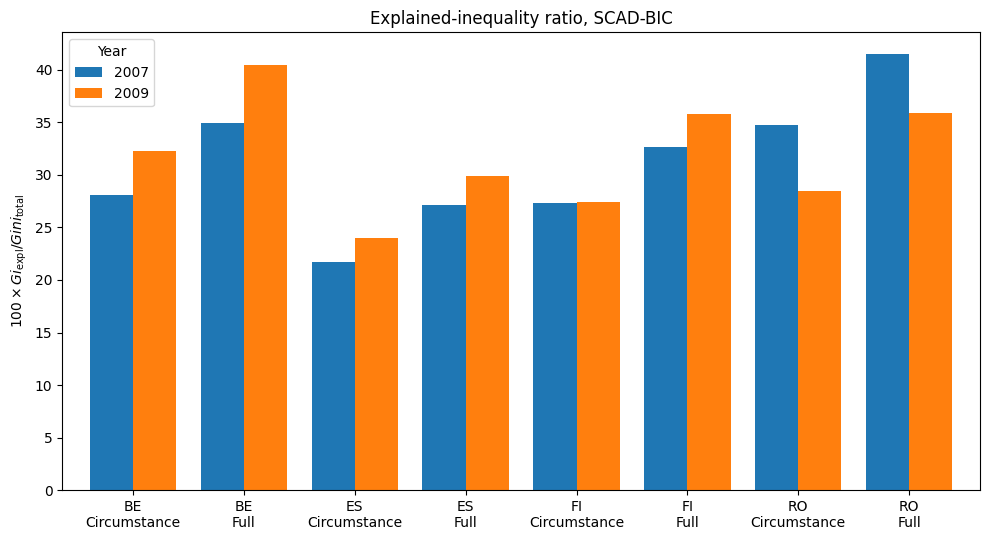

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data = [
    ["BE", "Circumstance", 0.280800, 0.322400],
    ["BE", "Full",         0.349000, 0.404400],
    ["ES", "Circumstance", 0.217400, 0.239900],
    ["ES", "Full",         0.271000, 0.298700],
    ["FI", "Circumstance", 0.273000, 0.274200],
    ["FI", "Full",         0.326900, 0.358000],
    ["RO", "Circumstance", 0.347400, 0.285000],
    ["RO", "Full",         0.415000, 0.359000],
]

df = pd.DataFrame(
    data,
    columns=["Country", "Specification", "LR_final_2007", "LR_final_2009"]
)

df["2007"] = df["LR_final_2007"] * 100
df["2009"] = df["LR_final_2009"] * 100

df["Group"] = df["Country"] + "\n" + df["Specification"]

plot_df = df.set_index("Group")[["2007", "2009"]]

ax = plot_df.plot(kind="bar", figsize=(10, 5.5), width=0.78)

ax.set_ylabel(r"$100 \times Gi_{\mathrm{expl}} / Gini_{\mathrm{total}}$")
ax.set_xlabel("")
ax.set_title("Explained-inequality ratio, SCAD-BIC")
ax.legend(title="Year")

plt.xticks(rotation=0)
plt.tight_layout()

outdir = Path("figures")
outdir.mkdir(exist_ok=True)

plt.savefig(outdir / "fig_explained_inequality_ratio_scad.png", dpi=300, bbox_inches="tight")
plt.savefig(outdir / "fig_explained_inequality_ratio_scad.pdf", bbox_inches="tight")
plt.show()

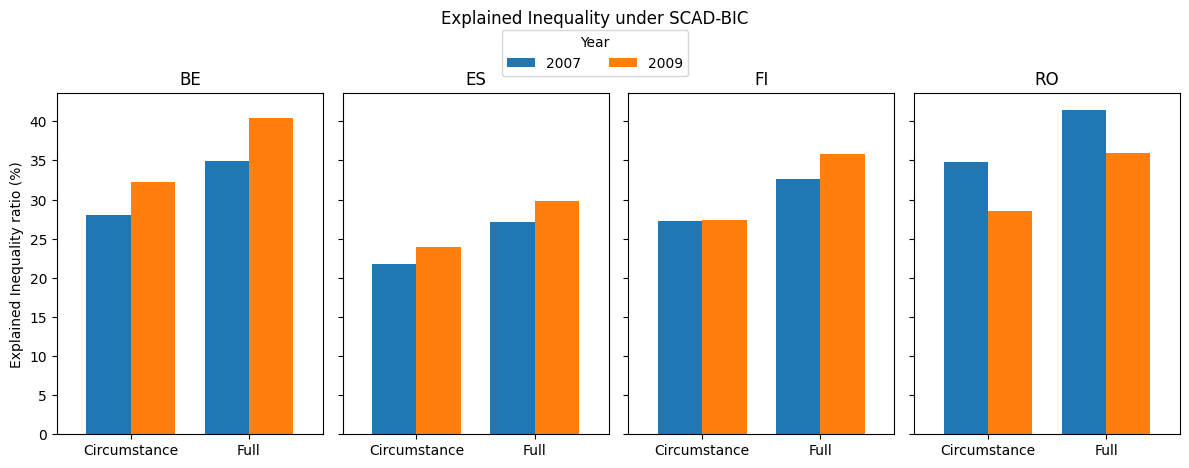

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

data = [
    ["BE", "Circumstance", 0.280800, 0.322400],
    ["BE", "Full",         0.349000, 0.404400],
    ["ES", "Circumstance", 0.217400, 0.239900],
    ["ES", "Full",         0.271000, 0.298700],
    ["FI", "Circumstance", 0.273000, 0.274200],
    ["FI", "Full",         0.326900, 0.358000],
    ["RO", "Circumstance", 0.347400, 0.285000],
    ["RO", "Full",         0.415000, 0.359000],
]

df = pd.DataFrame(
    data,
    columns=["Country", "Specification", "LR_final_2007", "LR_final_2009"]
)

df["2007"] = df["LR_final_2007"] * 100
df["2009"] = df["LR_final_2009"] * 100

countries = ["BE", "ES", "FI", "RO"]

fig, axes = plt.subplots(1, 4, figsize=(12, 4.5), sharey=True)

for ax, country in zip(axes, countries):
    sub = df[df["Country"] == country].set_index("Specification")[["2007", "2009"]]
    sub = sub.loc[["Circumstance", "Full"]]
    sub.plot(kind="bar", ax=ax, width=0.75, legend=False)
    ax.set_title(country)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=0)

axes[0].set_ylabel("Explained Inequality ratio (%)")
fig.suptitle("Explained Inequality under SCAD-BIC", y=1.03)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Year", loc="upper center", ncol=2, bbox_to_anchor=(0.5, 1.00))

plt.tight_layout()

outdir = Path("figures")
outdir.mkdir(exist_ok=True)

plt.savefig(outdir / "fig_explained_inequality_ratio_scad_faceted.png", dpi=300, bbox_inches="tight")
plt.savefig(outdir / "fig_explained_inequality_ratio_scad_faceted.pdf", bbox_inches="tight")
plt.show()

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd
from pathlib import Path

# =========================
# 1. Paths
# =========================

INFILE = Path("/content/drive/MyDrive/ALL_COUNTRIES_strict_audit_and_comparison_bundle.xlsx")
OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# =========================
# 2. Read data
# =========================

df = pd.read_excel(INFILE, sheet_name="final_long_all")
df.columns = [c.strip() for c in df.columns]

# Harmonised LR2
df["LR2_final"] = df["Gi_expl"] / df["Gini_total"]

# =========================
# 3. Standard labels
# =========================

country_order = ["BE", "ES", "FI", "RO"]
spec_order = ["Circumstance", "Full"]

# Adjust these if your file uses different labels
df["Specification"] = df["model_scope"].replace({
    "Extended": "Circumstance",
    "Circumstance": "Circumstance",
    "Full": "Full"
})

def clean_estimator(x):
    x = str(x).lower()
    if "scad" in x:
        return "SCAD-BIC"
    if "unpen" in x:
        return "Unpenalized"
    return x

df["Estimator"] = df["method"].apply(clean_estimator)

# =========================
# 4. Function to create same-format table
# =========================

def make_lorenz_table(df, estimator):
    tmp = df[df["Estimator"] == estimator].copy()

    wide = tmp.pivot_table(
        index=["country", "Specification"],
        columns="year",
        values=["Gini_total", "Gi_expl", "LR2_final"],
        aggfunc="first"
    )

    wide.columns = [f"{var}_{year}" for var, year in wide.columns]
    wide = wide.reset_index()

    # Sort
    wide["country_sort"] = wide["country"].apply(lambda x: country_order.index(x))
    wide["spec_sort"] = wide["Specification"].apply(lambda x: spec_order.index(x))
    wide = wide.sort_values(["country_sort", "spec_sort"])
    wide = wide.drop(columns=["country_sort", "spec_sort"])

    # Rename to match your SCAD-BIC table style
    wide = wide.rename(columns={
        "country": "Country",
        "Gini_total_2007": "Gini 2007",
        "Gini_total_2009": "Gini 2009",
        "Gi_expl_2007": "Expl. Gini 2007",
        "Gi_expl_2009": "Expl. Gini 2009",
        "LR2_final_2007": "LR2 2007",
        "LR2_final_2009": "LR2 2009",
    })

    # Fixed column order
    wide = wide[
        [
            "Country",
            "Specification",
            "Gini 2007",
            "Gini 2009",
            "Expl. Gini 2007",
            "Expl. Gini 2009",
            "LR2 2007",
            "LR2 2009",
        ]
    ]

    # Round to match your table
    num_cols = [
        "Gini 2007", "Gini 2009",
        "Expl. Gini 2007", "Expl. Gini 2009",
        "LR2 2007", "LR2 2009"
    ]
    wide[num_cols] = wide[num_cols].round(6)

    return wide

# =========================
# 5. Create tables
# =========================

unpen_table = make_lorenz_table(df, "Unpenalized")
scad_table = make_lorenz_table(df, "SCAD-BIC")

# =========================
# 6. Export CSV / Excel
# =========================

unpen_table.to_csv(OUTDIR / "table_unpenalized_lorenz_same_format.csv", index=False)
scad_table.to_csv(OUTDIR / "table_scad_bic_lorenz_same_format.csv", index=False)

with pd.ExcelWriter(OUTDIR / "lorenz_same_format_tables.xlsx", engine="openpyxl") as writer:
    unpen_table.to_excel(writer, sheet_name="unpenalized", index=False)
    scad_table.to_excel(writer, sheet_name="scad_bic", index=False)

# =========================
# 7. LaTeX export with same format
# =========================

def export_latex_same_format(table, caption, label, filename):
    lines = []
    lines.append(r"\begin{table}[H]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{{caption}}}")
    lines.append(rf"\label{{{label}}}")
    lines.append(r"\resizebox{\textwidth}{!}{%")
    lines.append(r"\begin{tabular}{llrrrrrr}")
    lines.append(r"\toprule")
    lines.append(
        r"Country & Specification & Gini 2007 & Gini 2009 & Expl. Gini 2007 & Expl. Gini 2009 & LR2 2007 & LR2 2009 \\"
    )
    lines.append(r"\midrule")

    for _, row in table.iterrows():
        lines.append(
            f"{row['Country']} & {row['Specification']} & "
            f"{row['Gini 2007']:.6f} & {row['Gini 2009']:.6f} & "
            f"{row['Expl. Gini 2007']:.6f} & {row['Expl. Gini 2009']:.6f} & "
            f"{row['LR2 2007']:.6f} & {row['LR2 2009']:.6f} \\\\"
        )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabular}%")
    lines.append(r"}")
    lines.append(r"\end{table}")

    latex = "\n".join(lines)
    (OUTDIR / filename).write_text(latex)
    return latex

unpen_latex = export_latex_same_format(
    unpen_table,
    "Total inequality and explained inequality, unpenalized Lorenz regression, 2007 and 2009",
    "tab:lorenz_unpenalized_results",
    "table_unpenalized_lorenz_same_format.tex"
)

scad_latex = export_latex_same_format(
    scad_table,
    "Total inequality and explained inequality, SCAD-BIC Lorenz regression, 2007 and 2009",
    "tab:lorenz_main_results",
    "table_scad_bic_lorenz_same_format.tex"
)

print("Saved to:", OUTDIR)
print("\nUnpenalized table:")
display(unpen_table)

print("\nSCAD-BIC table:")
display(scad_table)

Saved to: /content/drive/MyDrive/all_countries_results_tables

Unpenalized table:


,Country,Specification,Gini 2007,Gini 2009,Expl. Gini 2007,Expl. Gini 2009,LR2 2007,LR2 2009
0,BE,Circumstance,0.3464,0.3451,0.0920,0.1024,0.265589,0.296726
1,BE,Full,0.3464,0.3451,0.1141,0.1292,0.329388,0.374384
2,ES,Circumstance,0.3455,0.3673,0.0980,0.1112,0.283647,0.302750
3,ES,Full,0.3455,0.3673,0.1202,0.1242,0.347902,0.338143
4,FI,Circumstance,0.3502,0.3570,0.0976,0.1075,0.278698,0.301120
5,FI,Full,0.3502,0.3570,0.1170,0.1340,0.334095,0.375350
6,RO,Circumstance,0.3986,0.3609,0.1324,0.1166,0.332163,0.323081
7,RO,Full,0.3986,0.3609,0.1451,0.1392,0.364024,0.385702



SCAD-BIC table:


,Country,Specification,Gini 2007,Gini 2009,Expl. Gini 2007,Expl. Gini 2009,LR2 2007,LR2 2009
0,BE,Circumstance,0.3464,0.3451,0.0973,0.1113,0.280889,0.322515
1,BE,Full,0.3464,0.3451,0.1209,0.1396,0.349018,0.404520
2,ES,Circumstance,0.3455,0.3673,0.0751,0.0881,0.217366,0.239858
3,ES,Full,0.3455,0.3673,0.0936,0.1097,0.270912,0.298666
4,FI,Circumstance,0.3502,0.3570,0.0956,0.0979,0.272987,0.274230
5,FI,Full,0.3502,0.3570,0.1145,0.1278,0.326956,0.357983
6,RO,Circumstance,0.3986,0.3609,0.1385,0.1029,0.347466,0.285121
7,RO,Full,0.3986,0.3609,0.1654,0.1296,0.414952,0.359102


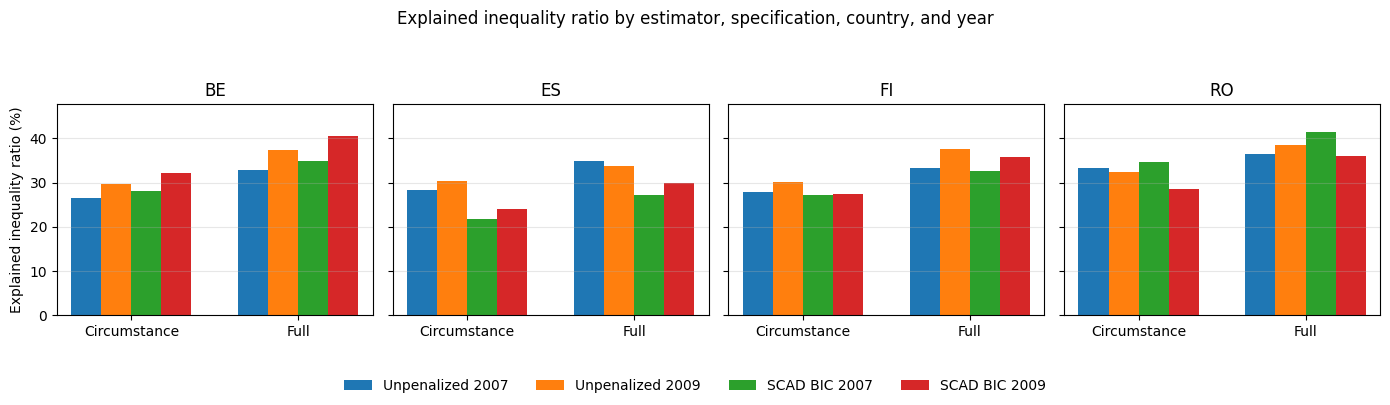

Saved:
/content/drive/MyDrive/all_countries_results_tables/figure_unpenalized_scad_bic_lr2_comparison.png
/content/drive/MyDrive/all_countries_results_tables/figure_unpenalized_scad_bic_lr2_comparison.pdf


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Paths
INFILE = Path("/content/drive/MyDrive/all_countries_results_tables/lorenz_same_format_tables.xlsx")
OUTDIR = Path("/content/drive/MyDrive/all_countries_results_tables")
OUTDIR.mkdir(parents=True, exist_ok=True)

# Read tables generated earlier
unpen = pd.read_excel(INFILE, sheet_name="unpenalized")
scad = pd.read_excel(INFILE, sheet_name="scad_bic")

unpen["Estimator"] = "Unpenalized"
scad["Estimator"] = "SCAD BIC"

df = pd.concat([unpen, scad], ignore_index=True)

# Convert wide to long for LR2
records = []
for _, row in df.iterrows():
    for year in [2007, 2009]:
        records.append({
            "Country": row["Country"],
            "Specification": row["Specification"],
            "Estimator": row["Estimator"],
            "Year": year,
            "LR2": row[f"LR2 {year}"] * 100
        })

plot_df = pd.DataFrame(records)

country_order = ["BE", "ES", "FI", "RO"]
spec_order = ["Circumstance", "Full"]
est_year_order = [
    ("Unpenalized", 2007),
    ("Unpenalized", 2009),
    ("SCAD BIC", 2007),
    ("SCAD BIC", 2009),
]

# Plot
fig, axes = plt.subplots(1, 4, figsize=(14, 4), sharey=True)

bar_width = 0.18
x = np.arange(len(spec_order))
offsets = np.array([-1.5, -0.5, 0.5, 1.5]) * bar_width

for ax, country in zip(axes, country_order):
    sub = plot_df[plot_df["Country"] == country]

    for j, (estimator, year) in enumerate(est_year_order):
        vals = []
        for spec in spec_order:
            value = sub[
                (sub["Specification"] == spec) &
                (sub["Estimator"] == estimator) &
                (sub["Year"] == year)
            ]["LR2"].iloc[0]
            vals.append(value)

        label = f"{estimator} {year}" if country == country_order[0] else None
        ax.bar(x + offsets[j], vals, width=bar_width, label=label)

    ax.set_title(country)
    ax.set_xticks(x)
    ax.set_xticklabels(spec_order, rotation=0)
    ax.set_ylim(0, max(plot_df["LR2"]) * 1.15)
    ax.grid(axis="y", alpha=0.3)

axes[0].set_ylabel("Explained inequality ratio (%)")
fig.suptitle("Explained inequality ratio by estimator, specification, country, and year")
fig.legend(loc="lower center", ncol=4, frameon=False)
fig.tight_layout(rect=[0, 0.12, 1, 0.92])

out_png = OUTDIR / "figure_unpenalized_scad_bic_lr2_comparison.png"
out_pdf = OUTDIR / "figure_unpenalized_scad_bic_lr2_comparison.pdf"

plt.savefig(out_png, dpi=300, bbox_inches="tight")
plt.savefig(out_pdf, bbox_inches="tight")
plt.show()

print("Saved:")
print(out_png)
print(out_pdf)

In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# Paths
# =========================================================

INFILE = Path("/content/drive/MyDrive/ALL_COUNTRIES_theta_analysis_bundle.xlsx")
OUTFILE = Path("/content/drive/MyDrive/all_countries_results_tables/table2_main_circumstance_discussed_3col.tex")

# =========================================================
# Read theta data
# =========================================================

raw = pd.read_excel(INFILE, sheet_name="all_theta_long")
raw.columns = [c.strip() for c in raw.columns]

# Use explicit columns only to avoid duplicate column names
df = raw[
    ["term", "theta", "country", "year", "method", "model_scope", "block"]
].copy()

df["theta"] = pd.to_numeric(df["theta"], errors="coerce")

df["model_scope"] = df["model_scope"].replace({
    "Extended": "Circumstance",
    "Circumstance": "Circumstance",
    "Full": "Full"
})

def clean_method(x):
    x = str(x).lower()
    if "scad" in x:
        return "SCAD BIC"
    if "unpen" in x:
        return "Unpenalized"
    return str(x)

df["method_clean"] = df["method"].apply(clean_method)

# Remove duplicate rows if the source file contains repeated entries
df = df.drop_duplicates(
    subset=["country", "year", "method_clean", "model_scope", "block", "term", "theta"]
).copy()

# =========================================================
# Old rows from your discussed circumstance table
# These values identify the same SCAD BIC coefficients in the theta file
# =========================================================

rows = [
    # Belgium
    ["Belgium", "BE", "Citizenship", "Non EU citizenship vs Belgian citizenship", -0.332300, "Non EU citizenship vs Belgian citizenship", -0.241700],
    ["Belgium", "BE", "Region", "Hainaut vs Brussels Capital Region", -0.301900, "Hainaut vs Brussels Capital Region", -0.398900],
    ["Belgium", "BE", "Age", "Age 65 plus vs 25 to 54", -0.444300, "Age 65 plus vs 25 to 54", -0.375100],
    ["Belgium", "BE", "Education", "Pre primary vs primary education", -0.277400, "Pre primary vs primary education", -0.199200],
    ["Belgium", "BE", "Health", "Bad health vs good health", -0.289700, "Very bad health vs good health", -0.375700],

    # Spain
    ["Spain", "ES", "Citizenship", "Non EU citizenship vs Spanish citizenship", -0.228900, "Non EU citizenship vs Spanish citizenship", -0.290600],
    ["Spain", "ES", "Region", "Ceuta vs Galicia", -0.378400, "Basque Country vs Galicia", 0.406100],
    ["Spain", "ES", "Age", "Age 65 plus vs 25 to 54", -0.176700, "Age 55 to 64 vs 25 to 54", 0.138700],
    ["Spain", "ES", "Education", "First stage tertiary vs primary education", 0.112400, "", np.nan],
    ["Spain", "ES", "Health", "Bad health vs good health", -0.200400, "Bad health vs good health", -0.126100],

    # Finland
    ["Finland", "FI", "Sex", "Female vs male", -0.192000, "", np.nan],
    ["Finland", "FI", "Citizenship", "", np.nan, "Non EU citizenship vs Finnish citizenship", -0.340700],
    ["Finland", "FI", "Region", "Southern Finland vs Western Finland", 0.231300, "Helsinki Uusimaa vs Western Finland", 0.352300],
    ["Finland", "FI", "Age", "Age 65 plus vs 25 to 54", -0.426200, "Age 15 to 24 vs 25 to 54", -0.470500],
    ["Finland", "FI", "Health", "Bad health vs good health", -0.463400, "Bad health vs good health", -0.351100],

    # Romania
    ["Romania", "RO", "Citizenship", "Another EU citizenship vs Romanian citizenship", -0.585900, "Another EU citizenship vs Romanian citizenship", 0.588400],
    ["Romania", "RO", "Region", "Bucharest Ilfov vs North East", 0.289500, "Bucharest Ilfov vs North East", 0.416200],
    ["Romania", "RO", "Age", "Age 65 plus vs 25 to 54", -0.403800, "Age 65 plus vs 25 to 54", -0.210200],
    ["Romania", "RO", "Health", "Very bad health vs good health", -0.348200, "Very bad health vs good health", -0.340400],
]

rows_df = pd.DataFrame(
    rows,
    columns=[
        "Country name", "country", "Covariate group",
        "Coefficient 2007", "SCAD BIC 2007 old",
        "Coefficient 2009", "SCAD BIC 2009 old"
    ]
)

# =========================================================
# Helper functions
# =========================================================

def find_term_by_scad_theta(country, year, target_theta, block, tolerance=0.001):
    if pd.isna(target_theta):
        return None

    sub = df[
        (df["country"] == country) &
        (df["year"] == year) &
        (df["model_scope"] == "Circumstance") &
        (df["method_clean"] == "SCAD BIC")
    ].copy()

    # Prefer same covariate block when available
    if "block" in sub.columns:
        block_sub = sub[sub["block"].astype(str).str.lower() == str(block).lower()]
        if not block_sub.empty:
            sub = block_sub.copy()

    sub["absdiff"] = (sub["theta"] - target_theta).abs()
    sub = sub[sub["absdiff"] <= tolerance]

    if sub.empty:
        return None

    sub = sub.sort_values("absdiff")
    return sub.iloc[0]["term"]


def get_theta(country, year, method, term):
    if term is None:
        return np.nan

    sub = df[
        (df["country"] == country) &
        (df["year"] == year) &
        (df["model_scope"] == "Circumstance") &
        (df["method_clean"] == method) &
        (df["term"] == term)
    ].copy()

    if sub.empty:
        return np.nan

    return sub.iloc[0]["theta"]


def fmt(x):
    if pd.isna(x):
        return ""
    return f"{x:.6f}"


def esc(s):
    if pd.isna(s):
        return ""
    s = str(s)
    s = s.replace("&", r"\&")
    s = s.replace("_", r"\_")
    return s

# =========================================================
# Build final table
# =========================================================

out_rows = []

for _, r in rows_df.iterrows():
    country = r["country"]
    block = r["Covariate group"]

    term_2007 = find_term_by_scad_theta(
        country, 2007, r["SCAD BIC 2007 old"], block
    )
    term_2009 = find_term_by_scad_theta(
        country, 2009, r["SCAD BIC 2009 old"], block
    )

    out_rows.append({
        "Country name": r["Country name"],
        "Covariate group": block,
        "Coefficient 2007": r["Coefficient 2007"],
        "Unpenalized 2007": get_theta(country, 2007, "Unpenalized", term_2007),
        "SCAD BIC 2007": get_theta(country, 2007, "SCAD BIC", term_2007),
        "Coefficient 2009": r["Coefficient 2009"],
        "Unpenalized 2009": get_theta(country, 2009, "Unpenalized", term_2009),
        "SCAD BIC 2009": get_theta(country, 2009, "SCAD BIC", term_2009),
    })

out = pd.DataFrame(out_rows)

print("Preview")
display(out)

print("Rows with missing values")
display(
    out[
        out[
            ["Unpenalized 2007", "SCAD BIC 2007", "Unpenalized 2009", "SCAD BIC 2009"]
        ].isna().any(axis=1)
    ]
)

# =========================================================
# Export one LaTeX file
# =========================================================

lines = []

lines.append(r"\begin{longtable}{p{0.12\textwidth}p{0.25\textwidth}rrp{0.25\textwidth}rr}")
lines.append(r"\caption{Selected SCAD BIC and unpenalized Lorenz regression circumstance coefficients discussed in the main text}")
lines.append(r"\label{tab:circumstance_discussed} \\")
lines.append(r"\toprule")
lines.append(r"Covariate group & 2007 coefficient & Unpenalized 2007 & SCAD BIC 2007 & 2009 coefficient & Unpenalized 2009 & SCAD BIC 2009 \\")
lines.append(r"\midrule")
lines.append(r"\endfirsthead")
lines.append("")
lines.append(r"\caption[]{Selected SCAD BIC and unpenalized Lorenz regression circumstance coefficients discussed in the main text} \\")
lines.append(r"\toprule")
lines.append(r"Covariate group & 2007 coefficient & Unpenalized 2007 & SCAD BIC 2007 & 2009 coefficient & Unpenalized 2009 & SCAD BIC 2009 \\")
lines.append(r"\midrule")
lines.append(r"\endhead")
lines.append("")
lines.append(r"\midrule")
lines.append(r"\multicolumn{7}{r}{Continued on next page} \\")
lines.append(r"\midrule")
lines.append(r"\endfoot")
lines.append("")
lines.append(r"\bottomrule")
lines.append(r"\endlastfoot")
lines.append("")

for country_name in ["Belgium", "Spain", "Finland", "Romania"]:
    lines.append(rf"\multicolumn{{7}}{{l}}{{\textit{{{country_name}}}}} \\")
    sub = out[out["Country name"] == country_name]

    for _, r in sub.iterrows():
        lines.append(
            f"{esc(r['Covariate group'])} & "
            f"{esc(r['Coefficient 2007'])} & {fmt(r['Unpenalized 2007'])} & {fmt(r['SCAD BIC 2007'])} & "
            f"{esc(r['Coefficient 2009'])} & {fmt(r['Unpenalized 2009'])} & {fmt(r['SCAD BIC 2009'])} \\\\"
        )

    if country_name != "Romania":
        lines.append(r"\midrule")

lines.append("")
lines.append(r"\end{longtable}")
lines.append("")
lines.append(r"\begin{flushleft}")
lines.append(r"\footnotesize")
lines.append(r"\textit{Notes:} Coefficients are components of the fitted single index rather than euro denominated marginal effects. The table reports circumstance specification coefficients discussed in the main text. SCAD BIC coefficients are selected by the penalized criterion. Unpenalized coefficients use all included covariate coefficients.")
lines.append(r"\end{flushleft}")

OUTFILE.write_text("\n".join(lines), encoding="utf-8")

print("Saved to:")
print(OUTFILE)

Preview


,Country name,Covariate group,Coefficient 2007,Unpenalized 2007,SCAD BIC 2007,Coefficient 2009,Unpenalized 2009,SCAD BIC 2009
0,Belgium,Citizenship,Non EU citizenship vs Belgian citizenship,-0.036010,-0.332317,Non EU citizenship vs Belgian citizenship,-0.037782,-0.241666
1,Belgium,Region,Hainaut vs Brussels Capital Region,-0.030015,-0.301943,Hainaut vs Brussels Capital Region,-0.067597,-0.398900
2,Belgium,Age,Age 65 plus vs 25 to 54,-0.073072,-0.444341,Age 65 plus vs 25 to 54,-0.114819,-0.375125
3,Belgium,Education,Pre primary vs primary education,-0.992858,-0.277442,Pre primary vs primary education,-0.064647,-0.199210
4,Belgium,Health,Bad health vs good health,-0.051319,-0.289655,Very bad health vs good health,-0.979830,-0.375743
5,Spain,Citizenship,Non EU citizenship vs Spanish citizenship,-0.055916,-0.228866,Non EU citizenship vs Spanish citizenship,-0.124344,-0.290575
6,Spain,Region,Ceuta vs Galicia,-0.265119,-0.378446,Basque Country vs Galicia,0.142079,0.406087
7,Spain,Age,Age 65 plus vs 25 to 54,-0.047677,-0.176701,Age 55 to 64 vs 25 to 54,0.051716,0.138732
8,Spain,Education,First stage tertiary vs primary education,0.028271,0.112437,,NaN,NaN
9,Spain,Health,Bad health vs good health,-0.053733,-0.200439,Bad health vs good health,-0.062022,-0.126099


Rows with missing values


,Country name,Covariate group,Coefficient 2007,Unpenalized 2007,SCAD BIC 2007,Coefficient 2009,Unpenalized 2009,SCAD BIC 2009
8,Spain,Education,First stage tertiary vs primary education,0.028271,0.112437,,NaN,NaN
10,Finland,Sex,Female vs male,-0.022335,-0.191989,,NaN,NaN
11,Finland,Citizenship,,NaN,NaN,Non EU citizenship vs Finnish citizenship,-0.064037,-0.340682


Saved to:
/content/drive/MyDrive/all_countries_results_tables/table2_main_circumstance_discussed_3col.tex


In [ ]:
import pandas as pd
import numpy as np
from pathlib import Path

# =========================================================
# Paths
# =========================================================

INFILE = Path("/content/drive/MyDrive/ALL_COUNTRIES_theta_analysis_bundle.xlsx")
OUTFILE = Path("/content/drive/MyDrive/all_countries_results_tables/table3_main_full_discussed_3col.tex")

# =========================================================
# Read theta data
# =========================================================

raw = pd.read_excel(INFILE, sheet_name="all_theta_long")
raw.columns = [c.strip() for c in raw.columns]

df = raw[
    ["term", "theta", "country", "year", "method", "model_scope", "block"]
].copy()

df["theta"] = pd.to_numeric(df["theta"], errors="coerce")

df["model_scope"] = df["model_scope"].replace({
    "Extended": "Circumstance",
    "Circumstance": "Circumstance",
    "Full": "Full"
})

def clean_method(x):
    x = str(x).lower()
    if "scad" in x:
        return "SCAD-BIC"
    if "unpen" in x:
        return "Unpenalized"
    return str(x)

df["method_clean"] = df["method"].apply(clean_method)

df = df.drop_duplicates(
    subset=["country", "year", "method_clean", "model_scope", "block", "term", "theta"]
).copy()

# =========================================================
# Full model rows discussed in the main text
# Old SCAD-BIC theta values are used only to identify the same term
# =========================================================

rows = [
    # Belgium
    ["Belgium", "BE", 2007, "Region", "Hainaut vs Brussels-Capital Region", -0.236300],
    ["Belgium", "BE", 2007, "Age", "Age 55--64 vs 25--54", 0.185200],
    ["Belgium", "BE", 2007, "Health", "Bad health vs good health", -0.146800],
    ["Belgium", "BE", 2007, "Economic status", "Domestic tasks and care responsibilities vs full-time work", -0.360200],
    ["Belgium", "BE", 2007, "Employment status", "Family workers vs employees", -0.289300],
    ["Belgium", "BE", 2007, "Housing", "Two rooms vs six or more rooms", -0.099500],

    ["Belgium", "BE", 2009, "Sex", "Female vs male", -0.014100],
    ["Belgium", "BE", 2009, "Region", "Hainaut vs Brussels-Capital Region", -0.237900],
    ["Belgium", "BE", 2009, "Age", "Age 65+ vs 25--54", -0.138700],
    ["Belgium", "BE", 2009, "Health", "Very bad health vs good health", -0.117700],
    ["Belgium", "BE", 2009, "Economic status", "Disabled or unable to work vs employee full-time", -0.383100],
    ["Belgium", "BE", 2009, "Employment status", "Family workers vs employees", -0.256700],
    ["Belgium", "BE", 2009, "Housing", "One room vs six or more rooms", -0.085600],

    # Spain
    ["Spain", "ES", 2007, "Citizenship", "Non-EU citizenship vs Spanish citizenship", -0.136800],
    ["Spain", "ES", 2007, "Region", "Madrid vs Galicia", 0.181700],
    ["Spain", "ES", 2007, "Health", "Bad health vs good health", -0.109500],
    ["Spain", "ES", 2007, "Economic status", "Domestic tasks and care responsibilities vs full-time work", -0.399100],
    ["Spain", "ES", 2007, "Employment status", "Family workers vs employees", -0.279700],
    ["Spain", "ES", 2007, "Housing", "Two rooms vs six or more rooms", -0.428200],

    ["Spain", "ES", 2009, "Citizenship", "Non-EU citizenship vs Spanish citizenship", -0.179300],
    ["Spain", "ES", 2009, "Region", "Basque Country vs Galicia", 0.317800],
    ["Spain", "ES", 2009, "Economic status", "Disabled or unable to work vs employee full-time", -0.318600],
    ["Spain", "ES", 2009, "Employment status", "Family workers vs employees", -0.196400],
    ["Spain", "ES", 2009, "Housing", "One room vs six or more rooms", -0.202100],

    # Finland
    ["Finland", "FI", 2007, "Region", "Southern Finland vs Western Finland", 0.130000],
    ["Finland", "FI", 2007, "Age", "Age 15--24 vs 25--54", -0.132900],
    ["Finland", "FI", 2007, "Health", "Bad health vs good health", -0.209900],
    ["Finland", "FI", 2007, "Economic status", "Other inactive status vs full-time work", -0.582000],
    ["Finland", "FI", 2007, "Employment status", "Family workers vs employees", -0.243400],

    ["Finland", "FI", 2009, "Sex", "Female vs male", -0.053600],
    ["Finland", "FI", 2009, "Region", "Helsinki-Uusimaa vs Western Finland", 0.105800],
    ["Finland", "FI", 2009, "Age", "Age 55--64 vs 25--54", 0.093400],
    ["Finland", "FI", 2009, "Economic status", "Unemployed vs employee full-time", -0.396400],
    ["Finland", "FI", 2009, "Employment status", "Family workers vs employees", -0.149600],
    ["Finland", "FI", 2009, "Housing", "One room vs six or more rooms", -0.148600],

    # Romania
    ["Romania", "RO", 2007, "Citizenship", "Another EU citizenship vs Romanian citizenship", -0.411700],
    ["Romania", "RO", 2007, "Health", "Very bad health vs good health", -0.179100],
    ["Romania", "RO", 2007, "Economic status", "Disabled or unable to work vs full-time work", -0.441800],
    ["Romania", "RO", 2007, "Employment status", "Family workers vs employees", -0.195100],
    ["Romania", "RO", 2007, "Housing", "One room vs six or more rooms", -0.136800],

    ["Romania", "RO", 2009, "Region", "Bucharest-Ilfov vs North-East", 0.241500],
    ["Romania", "RO", 2009, "Health", "Very bad health vs good health", -0.154400],
    ["Romania", "RO", 2009, "Economic status", "Student or training vs employee full-time", -0.329600],
    ["Romania", "RO", 2009, "Employment status", "Family workers vs employees", -0.199600],
]

rows_df = pd.DataFrame(
    rows,
    columns=["Country name", "country", "year", "Covariate group", "Coefficient", "SCAD old"]
)

# =========================================================
# Helper functions
# =========================================================

def find_term_by_scad_theta(country, year, target_theta, block, tolerance=0.0015):
    sub = df[
        (df["country"] == country) &
        (df["year"] == year) &
        (df["model_scope"] == "Full") &
        (df["method_clean"] == "SCAD-BIC")
    ].copy()

    block_sub = sub[sub["block"].astype(str).str.lower() == str(block).lower()]
    if not block_sub.empty:
        sub = block_sub.copy()

    sub["absdiff"] = (sub["theta"] - target_theta).abs()
    sub = sub[sub["absdiff"] <= tolerance]

    if sub.empty:
        return None

    sub = sub.sort_values("absdiff")
    return sub.iloc[0]["term"]

def get_theta(country, year, method, term):
    if term is None:
        return np.nan

    sub = df[
        (df["country"] == country) &
        (df["year"] == year) &
        (df["model_scope"] == "Full") &
        (df["method_clean"] == method) &
        (df["term"] == term)
    ].copy()

    if sub.empty:
        return np.nan

    return sub.iloc[0]["theta"]

def fmt(x):
    if pd.isna(x):
        return ""
    return f"{x:.6f}"

def esc(s):
    if pd.isna(s):
        return ""
    s = str(s)
    return s.replace("&", r"\&").replace("_", r"\_")

# =========================================================
# Build final data
# =========================================================

out_rows = []

for _, r in rows_df.iterrows():
    term = find_term_by_scad_theta(
        r["country"],
        r["year"],
        r["SCAD old"],
        r["Covariate group"]
    )

    out_rows.append({
        "Country name": r["Country name"],
        "country": r["country"],
        "year": r["year"],
        "Covariate group": r["Covariate group"],
        "Coefficient": r["Coefficient"],
        "Unpenalized": get_theta(r["country"], r["year"], "Unpenalized", term),
        "SCAD-BIC": get_theta(r["country"], r["year"], "SCAD-BIC", term),
    })

out = pd.DataFrame(out_rows)

print("Preview")
display(out)

print("Rows with missing values")
display(out[out[["Unpenalized", "SCAD-BIC"]].isna().any(axis=1)])

# =========================================================
# Export LaTeX: one file, four separate country tables
# =========================================================

country_order = ["Belgium", "Spain", "Finland", "Romania"]
label_map = {
    "Belgium": "belgium",
    "Spain": "spain",
    "Finland": "finland",
    "Romania": "romania"
}

lines = []

for country_name in country_order:
    label_country = label_map[country_name]
    sub = out[out["Country name"] == country_name].copy()

    lines.append(r"\begin{table}[H]")
    lines.append(r"\centering")
    lines.append(rf"\caption{{Selected SCAD-BIC and unpenalized Lorenz regression full model coefficients for {country_name}}}")
    lines.append(rf"\label{{tab:full_{label_country}}}")
    lines.append(r"\begin{tabularx}{\textwidth}{llXrr}")
    lines.append(r"\toprule")
    lines.append(r"Year & Covariate group & Coefficient & Unpenalized & SCAD-BIC \\")
    lines.append(r"\midrule")

    years = sorted(sub["year"].unique())

    for idx, year in enumerate(years):
        if idx > 0:
            lines.append(r"\midrule")

        sub_year = sub[sub["year"] == year]

        for _, row in sub_year.iterrows():
            lines.append(
                f"{int(row['year'])} & "
                f"{esc(row['Covariate group'])} & "
                f"{esc(row['Coefficient'])} & "
                f"{fmt(row['Unpenalized'])} & "
                f"{fmt(row['SCAD-BIC'])} \\\\"
            )

    lines.append(r"\bottomrule")
    lines.append(r"\end{tabularx}")
    lines.append(r"\end{table}")
    lines.append("")
    lines.append("")

OUTFILE.write_text("\n".join(lines), encoding="utf-8")

print("Saved to:")
print(OUTFILE)

Preview


,Country name,country,year,Covariate group,Coefficient,Unpenalized,SCAD-BIC
0,Belgium,BE,2007,Region,Hainaut vs Brussels-Capital Region,-0.091717,-0.236335
1,Belgium,BE,2007,Age,Age 55--64 vs 25--54,0.098221,0.185156
2,Belgium,BE,2007,Health,Bad health vs good health,-0.098695,-0.146766
3,Belgium,BE,2007,Economic status,Domestic tasks and care responsibilities vs fu...,-0.288479,-0.360165
4,Belgium,BE,2007,Employment status,Family workers vs employees,-0.123008,-0.289287
5,Belgium,BE,2007,Housing,Two rooms vs six or more rooms,-0.062512,-0.099466
6,Belgium,BE,2009,Sex,Female vs male,-0.013367,-0.014134
7,Belgium,BE,2009,Region,Hainaut vs Brussels-Capital Region,-0.109178,-0.237928
8,Belgium,BE,2009,Age,Age 65+ vs 25--54,-0.126057,-0.138703
9,Belgium,BE,2009,Health,Very bad health vs good health,-0.056531,-0.117675


Rows with missing values


,Country name,country,year,Covariate group,Coefficient,Unpenalized,SCAD-BIC


Saved to:
/content/drive/MyDrive/all_countries_results_tables/table3_main_full_discussed_3col.tex
